## 00. load package

✅ 模块重新加载完成
📁 数据保存目录: ./processed_data
📁 图形保存目录: ./figures/Cal_radiation/


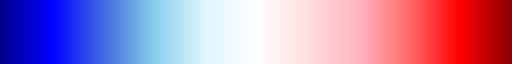

In [1]:

import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import easygems.healpix as egh
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from typing import Tuple, List, Optional, Union, Dict
import scipy.signal as signal
from global_land_mask import globe
import math
import time
import os
import pickle
from scipy import fft
import cmaps  
from typing import Optional
import sys
import matplotlib.colors as mcolors
import importlib
sys.path.append("/home/m/m301257/wave_tools")
from wave_tools.utils import dataarray_to_equatorial_latlon_grid,get_region_healpix_,create_cmap_from_string,dataarray_healpix_to_equatorial_latlon
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave    
# 重新导入修复后的模块
import wave_tools.spectral
import wave_tools.plotting
importlib.reload(wave_tools.spectral)
importlib.reload(wave_tools.plotting)
from wave_tools.spectral import WKSpectralAnalysis, SpectralConfig
from wave_tools.plotting import set_axis_for_wave
from wave_tools import matsuno as mp
print("="*70)
print("✅ 模块重新加载完成")
print("="*70)
import mpi4py
import logging
import glob

DATA_DIR = "./processed_data"
os.makedirs(DATA_DIR, exist_ok=True)
fig_save_dir = "./figures/Cal_radiation/"
os.makedirs(fig_save_dir, exist_ok=True)
print("="*70)
print(f"📁 数据保存目录: {DATA_DIR}")
print(f"📁 图形保存目录: {fig_save_dir}")
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """创建改进的红-白-蓝配色"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()
mycmap

In [2]:
# 处理陆地-海洋掩膜

if os.path.exists(os.path.join(DATA_DIR, "ocean_mask_2deg.nc")):
    print("="*70)
    print("✅ 发现已保存的海洋掩膜数据")
    print("   正在加载...")
    ocean_mask_2deg_binary = xr.open_dataarray(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))
    print(f"   加载完成! 形状: {ocean_mask_2deg_binary.shape}")
else:
    print("❌ 未找到已保存的海洋掩膜数据")
    
def _ocean(ds):
    fraction = xr.open_dataset(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))['__xarray_dataarray_variable__']
    return fraction == 1

✅ 发现已保存的海洋掩膜数据
   正在加载...
   加载完成! 形状: (15, 180)


In [3]:
# 步骤6.1: 加载辐射通量数据
print("="*70)
print("📊 加载辐射通量数据")
print("="*70)

# 定义辐射变量（选择最关键的变量进行分析）
rad_vars = {
    'rlus': 'Surface Upwelling Longwave',       # 地表上行长波, 进入大气
    'rsdt': 'TOA Incident Solar',               # 大气顶入射太阳辐射, 进入大气
    'rsus': 'Surface Upwelling Shortwave' ,     # 地表上行短波, 进入大气
    
    'rsds': 'Surface Downwelling Shortwave',    # 地表下行短波, 离开大气
    'rsut': 'TOA Outgoing Shortwave',           # 大气顶外逸短波, 离开大气
    'rlut': 'TOA Outgoing Longwave (OLR)',      # 大气顶外逸长波, 离开大气
    'rlds': 'Surface Downwelling Longwave',     # 地表下行长波, 离开大气
    
    'hfls': 'Surface Upward Latent Heat Flux', # 地表向上潜热通量, 进入大气， 需要乘上-1
    'hfss': 'Surface Upward Sensible Heat Flux' # 地表向上感热通量, 进入大气， 需要乘上-1
}

LAYER_DIR = "/work/mh1498/m301257/processed_data/2d_layers"

experiments = ["cntl", "p4k", "4co2"]
rad_data = {}

# 加载所有辐射数据并直接应用海洋mask
for var, var_name in rad_vars.items():
    print(f"\n🔄 加载 {var} ({var_name})...")
    rad_data[var] = {}
    
    for exp in experiments:
        file_path = os.path.join(LAYER_DIR, f"{var}_{exp}/{var}_2deg_interp.nc")
        
        try:
            if var in ["hfls", "hfss"]:
                # 对于潜热和感热通量，加载后乘以-1，并应用海洋mask
                data_temp = -xr.open_dataarray(file_path)
                rad_data[var][exp.upper() if exp != "4co2" else "4CO2"] = data_temp.where(ocean_mask_2deg_binary == 1)
            else:
                # 加载并应用海洋mask
                data_temp = xr.open_dataarray(file_path)
                rad_data[var][exp.upper() if exp != "4co2" else "4CO2"] = data_temp.where(ocean_mask_2deg_binary == 1)
            print(f"   ✅ {exp.upper()}: {rad_data[var][exp.upper() if exp != '4co2' else '4CO2'].shape} (ocean only)")
        except Exception as e:
            print(f"   ❌ {exp.upper()}: 加载失败 - {str(e)}")

print("\n" + "="*70)
print("✅ 辐射数据加载完成")
print("="*70)

📊 加载辐射通量数据

🔄 加载 rlus (Surface Upwelling Longwave)...
   ✅ CNTL: (5114, 15, 180) (ocean only)
   ✅ P4K: (5114, 15, 180) (ocean only)
   ✅ 4CO2: (5114, 15, 180) (ocean only)

🔄 加载 rsdt (TOA Incident Solar)...
   ✅ CNTL: (5114, 15, 180) (ocean only)
   ✅ P4K: (5114, 15, 180) (ocean only)
   ✅ 4CO2: (5114, 15, 180) (ocean only)

🔄 加载 rsus (Surface Upwelling Shortwave)...
   ✅ CNTL: (5114, 15, 180) (ocean only)
   ✅ P4K: (5114, 15, 180) (ocean only)
   ✅ 4CO2: (5114, 15, 180) (ocean only)

🔄 加载 rsds (Surface Downwelling Shortwave)...
   ✅ CNTL: (5114, 15, 180) (ocean only)
   ✅ P4K: (5114, 15, 180) (ocean only)
   ✅ 4CO2: (5114, 15, 180) (ocean only)

🔄 加载 rsut (TOA Outgoing Shortwave)...
   ✅ CNTL: (5114, 15, 180) (ocean only)
   ✅ P4K: (5114, 15, 180) (ocean only)
   ✅ 4CO2: (5114, 15, 180) (ocean only)

🔄 加载 rlut (TOA Outgoing Longwave (OLR))...
   ✅ CNTL: (5114, 15, 180) (ocean only)
   ✅ P4K: (5114, 15, 180) (ocean only)
   ✅ 4CO2: (5114, 15, 180) (ocean only)

🔄 加载 rlds (Surface Down

In [4]:
# 步骤6.2: 计算气候态和辐射通量差异
print("="*70)
print("🧮 计算辐射通量气候态和差异")
print("="*70)

# 1. 计算时间平均（气候态）
rad_clim = {}
for var in rad_vars.keys():
    rad_clim[var] = {}
    for exp in ["CNTL", "P4K", "4CO2"]:
        rad_clim[var][exp] = rad_data[var][exp].mean(dim='time')
        print(f"✅ {var} - {exp} 气候态计算完成")

# 2. 计算相对于CNTL的差异
rad_diff = {}
for var in rad_vars.keys():
    rad_diff[var] = {
        "P4K-CNTL": rad_clim[var]["P4K"] - rad_clim[var]["CNTL"],
        "4CO2-CNTL": rad_clim[var]["4CO2"] - rad_clim[var]["CNTL"]
    }

# 3. 计算热带平均（15°S-15°N）
def tropical_mean_rad(data, lat_range=(-15, 15)):
    """计算热带平均"""
    return (data).sel(lat=slice(*lat_range)).mean(dim=['lat', 'lon'])

rad_tropical = {}
for var in rad_vars.keys():
    rad_tropical[var] = {exp: tropical_mean_rad(data) 
                         for exp, data in rad_clim[var].items()}

# 4. 打印辐射通量统计
print("\n" + "="*70)
print("📊 热带平均辐射通量 (W/m²)")
print("="*70)
print(f"{'变量':<8} {'CNTL':<15} {'P4K':<15} {'4CO2':<15}")
print("-"*70)

for var, var_name in rad_vars.items():
    cntl_val = float(rad_tropical[var]["CNTL"])
    p4k_val = float(rad_tropical[var]["P4K"])
    co2_val = float(rad_tropical[var]["4CO2"])
    print(f"{var:<8} {cntl_val:<15.2f} {p4k_val:<15.2f} {co2_val:<15.2f}")

print("\n" + "="*70)
print("📊 相对CNTL的辐射通量变化 (W/m²)")
print("="*70)
print(f"{'变量':<8} {'P4K-CNTL':<15} {'4CO2-CNTL':<15} {'差异(4CO2-P4K)':<15}")
print("-"*70)

rad_changes = {}
for var in rad_vars.keys():
    dp4k = float(tropical_mean_rad(rad_diff[var]["P4K-CNTL"]))
    dco2 = float(tropical_mean_rad(rad_diff[var]["4CO2-CNTL"]))
    diff_exp = dco2 - dp4k
    
    rad_changes[var] = {
        'P4K-CNTL': dp4k,
        '4CO2-CNTL': dco2,
        'diff': diff_exp
    }
    
    print(f"{var:<8} {dp4k:<15.2f} {dco2:<15.2f} {diff_exp:<15.2f}")

print("="*70)

🧮 计算辐射通量气候态和差异
✅ rlus - CNTL 气候态计算完成
✅ rlus - P4K 气候态计算完成
✅ rlus - 4CO2 气候态计算完成
✅ rsdt - CNTL 气候态计算完成
✅ rsdt - P4K 气候态计算完成
✅ rsdt - 4CO2 气候态计算完成
✅ rsus - CNTL 气候态计算完成
✅ rsus - P4K 气候态计算完成
✅ rsus - 4CO2 气候态计算完成
✅ rsds - CNTL 气候态计算完成
✅ rsds - P4K 气候态计算完成
✅ rsds - 4CO2 气候态计算完成
✅ rsut - CNTL 气候态计算完成
✅ rsut - P4K 气候态计算完成
✅ rsut - 4CO2 气候态计算完成
✅ rlut - CNTL 气候态计算完成
✅ rlut - P4K 气候态计算完成
✅ rlut - 4CO2 气候态计算完成
✅ rlds - CNTL 气候态计算完成
✅ rlds - P4K 气候态计算完成
✅ rlds - 4CO2 气候态计算完成
✅ hfls - CNTL 气候态计算完成
✅ hfls - P4K 气候态计算完成
✅ hfls - 4CO2 气候态计算完成
✅ hfss - CNTL 气候态计算完成
✅ hfss - P4K 气候态计算完成
✅ hfss - 4CO2 气候态计算完成

📊 热带平均辐射通量 (W/m²)
变量       CNTL            P4K             4CO2           
----------------------------------------------------------------------
rlus     463.14          488.35          463.17         
rsdt     411.39          411.39          411.39         
rsus     17.35           17.19           17.33          
rsds     246.84          244.44          246.48         
rsut     89.26           


### 🔬 关键物理意义：

**Qrad的作用：**
1. **驱动大气环流**：辐射加热不均匀 → 温度梯度 → 大气运动
2. **影响对流活动**：Qrad增加 → 大气不稳定 → 对流增强
3. **与潜热协同**：辐射加热 + 潜热释放 = 总的大气加热
4. **反映气候响应**：ΔQrad反映了气候系统对外部强迫的响应

**P4K vs 4CO2的差异：**
- **P4K**: 主要由SST升高驱动，蒸发和潜热通量变化更显著
- **4CO2**: CO₂辐射强迫主导，大气辐射加热变化更直接
- 两者对MSE和EOF结构的影响机制不同

## 步骤5: 净能量通量分析 (Net Energy Flux Analysis)

根据能量平衡方程计算和分析大气柱的净能量通量：

**进入大气柱的净能量通量：**
$$F_{net} = F_{in} - F_{out}$$

**能量通量（进入大气）：**
$$F_{in} = SW_{toa}^{\downarrow} + LW_{surf}^{\uparrow} + SW_{surf}^{\uparrow} + LH + SH$$

- $SW_{toa}^{\downarrow}$ (rsdt): 大气顶入射太阳辐射
- $LW_{surf}^{\uparrow}$ (rlus): 地表上行长波  
- $SW_{surf}^{\uparrow}$ (rsus): 地表上行短波
- $E$ (hfls): 地表向上潜热通量
- $H$ (hfss): 地表向上感热通量

**能量通量（离开大气）：**
$$F_{out} = SW_{toa}^{\uparrow} + LW_{toa}^{\uparrow} + SW_{surf}^{\downarrow} + LW_{surf}^{\downarrow} $$

其中：
- $SW_{toa}^{\uparrow}$ (rsut): 大气顶外逸短波
- $LW_{toa}^{\uparrow}$ (rlut): 大气顶外逸长波
- $SW_{surf}^{\downarrow}$ (rsds): 地表下行短波
- $LW_{surf}^{\downarrow}$ (rlds): 地表下行长波



In [5]:
rad_clim.keys()
for var in rad_vars.keys():
    print(f"{var}:")
    for exp in ["CNTL", "P4K", "4CO2"]:
        data = rad_clim[var][exp]
        mean_val = float(tropical_mean_rad(data))
        print(f"  {exp} mean: {mean_val:.2f} W/m²")

rlus:
  CNTL mean: 463.14 W/m²
  P4K mean: 488.35 W/m²
  4CO2 mean: 463.17 W/m²
rsdt:
  CNTL mean: 411.39 W/m²
  P4K mean: 411.39 W/m²
  4CO2 mean: 411.39 W/m²
rsus:
  CNTL mean: 17.35 W/m²
  P4K mean: 17.19 W/m²
  4CO2 mean: 17.33 W/m²
rsds:
  CNTL mean: 246.84 W/m²
  P4K mean: 244.44 W/m²
  4CO2 mean: 246.48 W/m²
rsut:
  CNTL mean: 89.26 W/m²
  P4K mean: 85.51 W/m²
  4CO2 mean: 88.09 W/m²
rlut:
  CNTL mean: 260.83 W/m²
  P4K mean: 267.34 W/m²
  4CO2 mean: 253.09 W/m²
rlds:
  CNTL mean: 405.56 W/m²
  P4K mean: 440.01 W/m²
  4CO2 mean: 410.16 W/m²
hfls:
  CNTL mean: 131.49 W/m²
  P4K mean: 148.32 W/m²
  4CO2 mean: 124.57 W/m²
hfss:
  CNTL mean: 11.85 W/m²
  P4K mean: 10.40 W/m²
  4CO2 mean: 10.63 W/m²


In [6]:
# 步骤8.2: 计算净能量通量
print("="*70)
print("🧮 计算净能量通量 (Net Energy Flux)")
print("="*70)


# 计算 F_in(进入大气)
# F_in = rsdt + rlus + rsus + hfls + hfss
F_in = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    required_vars = ['rsdt', 'rlus', 'rsus', 'hfls', 'hfss']
    if all(v in rad_clim for v in required_vars):
        F_in[exp] = (rad_clim['rsdt'][exp] + 
                     rad_clim['rlus'][exp] + 
                     rad_clim['rsus'][exp] + 
                     rad_clim['hfls'][exp] +
                     rad_clim['hfss'][exp])
        print(f"{exp} F_in = {float(F_in[exp].mean()):.2f} W/m²")
                   


# 计算 F_out (离开大气的净通量)
# F_out = rsut + rlut + rsds + rlds
F_out = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    required_vars = ['rsut', 'rlut', 'rsds', 'rlds']
    if all(v in rad_clim for v in required_vars):
        F_out[exp] = (rad_clim['rsut'][exp] + 
                      rad_clim['rlut'][exp] + 
                      rad_clim['rsds'][exp] + 
                      rad_clim['rlds'][exp])
        print(f"{exp} F_out = {float(F_out[exp].mean()):.2f} W/m²")


# 计算 F_net (进入大气柱的净能量通量)
# F_net = F_in - F_out

F_net = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    if exp in F_in and exp in F_out:
        F_net[exp] = F_in[exp] - F_out[exp]

        print(f"\n{'='*50}")
        print(f"{exp} 能量平衡:")
        print(f"{'='*50}")
        print(f"  F_in  = {float(F_in[exp].mean()):8.2f} W/m² (TOA进入)")
        print(f"  F_out  = {float(F_out[exp].mean()):8.2f} W/m² (地表进入)")
        print(f"  F_net  = {float(F_net[exp].mean()):8.2f} W/m² (大气柱净收支)")
        print(f"{'='*50}")

print("\n" + "="*70)
print("✅ 净能量通量计算完成")
print("="*70)

🧮 计算净能量通量 (Net Energy Flux)
CNTL F_in = 1035.23 W/m²
P4K F_in = 1075.64 W/m²
4CO2 F_in = 1027.09 W/m²
CNTL F_out = 1002.49 W/m²
P4K F_out = 1037.30 W/m²
4CO2 F_out = 997.83 W/m²

CNTL 能量平衡:
  F_in  =  1035.23 W/m² (TOA进入)
  F_out  =  1002.49 W/m² (地表进入)
  F_net  =    32.74 W/m² (大气柱净收支)

P4K 能量平衡:
  F_in  =  1075.64 W/m² (TOA进入)
  F_out  =  1037.30 W/m² (地表进入)
  F_net  =    38.34 W/m² (大气柱净收支)

4CO2 能量平衡:
  F_in  =  1027.09 W/m² (TOA进入)
  F_out  =   997.83 W/m² (地表进入)
  F_net  =    29.27 W/m² (大气柱净收支)

✅ 净能量通量计算完成


In [7]:
# 步骤8.3: 应用海洋mask并计算差异
print("="*70)
print("🌊 应用海洋掩膜并计算实验间差异")
print("="*70)

# 应用海洋mask
F_in_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_in.items()}
F_out_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_out.items()}
F_net_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_net.items()}

# 计算热带平均（海洋）
def tropical_mean_flux(data, lat_range=(-15, 15)):
    """计算热带平均（去除NaN）"""
    return data.sel(lat=slice(*lat_range)).mean(dim=['lat', 'lon'])

print("\n海洋区域热带平均 (15°S-15°N):")
print("="*70)
print(f"{'实验':<10} {'F_in':<15} {'F_out':<15} {'F_net':<15}")
print("-"*70)

for exp in ["CNTL", "P4K", "4CO2"]:
    ftop_mean = float(tropical_mean_flux(F_in_ocean[exp]))
    fsur_mean = float(tropical_mean_flux(F_out_ocean[exp]))
    fnet_mean = float(tropical_mean_flux(F_net_ocean[exp]))
    print(f"{exp:<10} {ftop_mean:>14.2f} {fsur_mean:>14.2f} {fnet_mean:>14.2f}")

# 计算相对CNTL的差异（海洋）
F_in_diff_ocean = {
    "P4K-CNTL": F_in_ocean["P4K"] - F_in_ocean["CNTL"],
    "4CO2-CNTL": F_in_ocean["4CO2"] - F_in_ocean["CNTL"]
}

F_out_diff_ocean = {
    "P4K-CNTL": F_out_ocean["P4K"] - F_out_ocean["CNTL"],
    "4CO2-CNTL": F_out_ocean["4CO2"] - F_out_ocean["CNTL"]
}

F_net_diff_ocean = {
    "P4K-CNTL": F_net_ocean["P4K"] - F_net_ocean["CNTL"],
    "4CO2-CNTL": F_net_ocean["4CO2"] - F_net_ocean["CNTL"]
}

print("\n" + "="*70)
print("实验差异（相对CNTL，海洋）:")
print("="*70)
print(f"{'差异':<12} {'ΔF_in':<15} {'ΔF_out':<15} {'ΔF_net':<15}")
print("-"*70)

for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    dfin = float(tropical_mean_flux(F_in_diff_ocean[diff_name]))
    dfout = float(tropical_mean_flux(F_out_diff_ocean[diff_name]))
    dfnet = float(tropical_mean_flux(F_net_diff_ocean[diff_name]))
    print(f"{diff_name:<12} {dfin:>14.2f} {dfout:>14.2f} {dfnet:>14.2f}")



🌊 应用海洋掩膜并计算实验间差异

海洋区域热带平均 (15°S-15°N):
实验         F_in            F_out           F_net          
----------------------------------------------------------------------
CNTL              1035.23        1002.49          32.74
P4K               1075.64        1037.30          38.34
4CO2              1027.09         997.83          29.27

实验差异（相对CNTL，海洋）:
差异           ΔF_in           ΔF_out          ΔF_net         
----------------------------------------------------------------------
P4K-CNTL              40.41          34.81           5.60
4CO2-CNTL             -8.13          -4.66          -3.47


📊 可视化各实验的能量通量气候态空间分布（3x3布局）
✅ 已保存: ./figures/Cal_radiation/energy_flux_climatology_3x3_ocean.png


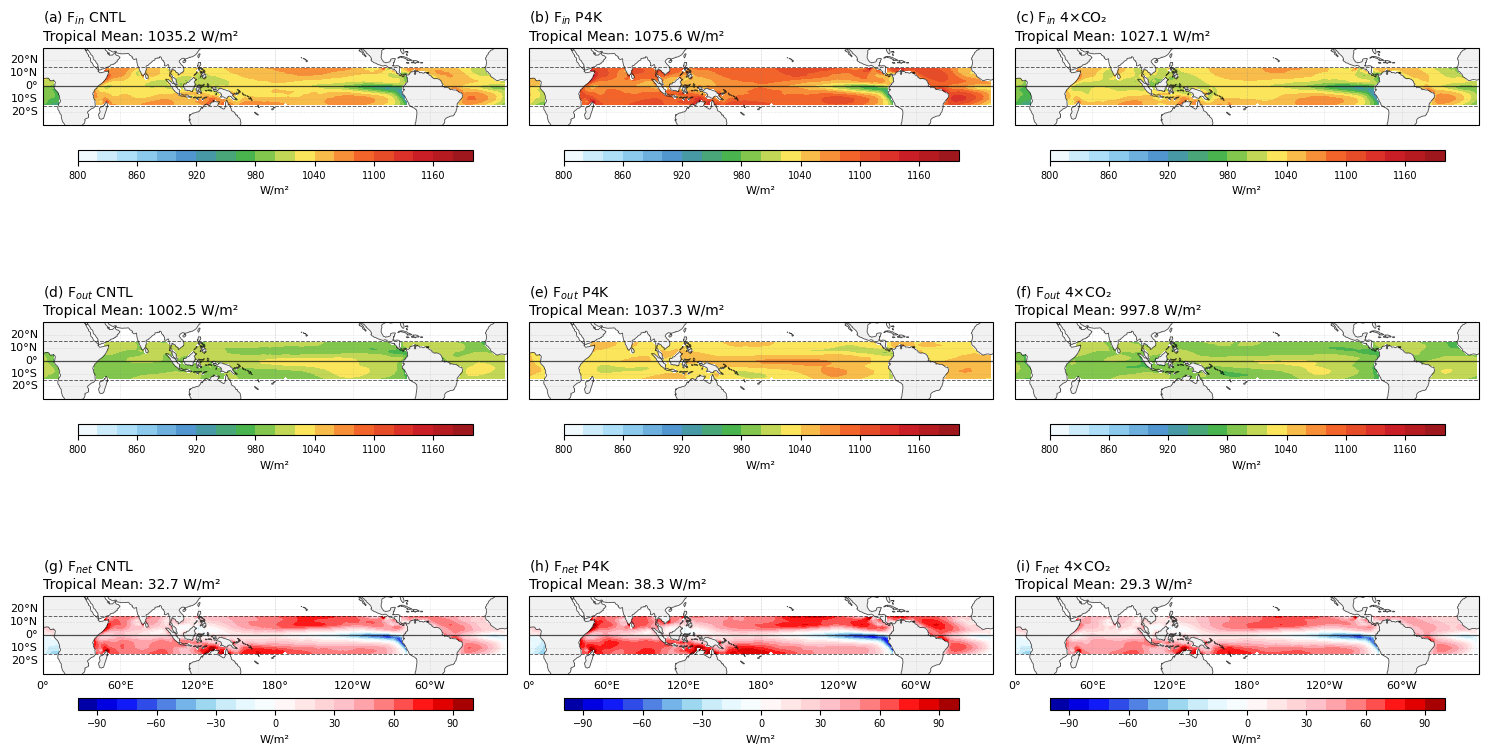

In [8]:
# 步骤8.4: 可视化各实验的能量通量气候态空间分布
print("="*70)
print("📊 可视化各实验的能量通量气候态空间分布（3x3布局）")
print("="*70)

# 准备9个字段数据（3个实验 × 3个通量）
field_list_clim = [
    F_in_ocean["CNTL"], F_in_ocean["P4K"], F_in_ocean["4CO2"],
    F_out_ocean["CNTL"], F_out_ocean["P4K"], F_out_ocean["4CO2"],
    F_net_ocean["CNTL"], F_net_ocean["P4K"], F_net_ocean["4CO2"]
]

titles_clim = [
    '(a) F$_{in}$ CNTL', '(b) F$_{in}$ P4K', '(c) F$_{in}$ 4×CO₂',
    '(d) F$_{out}$ CNTL', '(e) F$_{out}$ P4K', '(f) F$_{out}$ 4×CO₂',
    '(g) F$_{net}$ CNTL', '(h) F$_{net}$ P4K', '(i) F$_{net}$ 4×CO₂'
]

# 颜色映射与范围设置（相同类型的通量使用相同范围）
cmaps_clim = [
    cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed,  # F_in
    cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed,  # F_out
    mycmap, mycmap, mycmap  # F_net
]

# 设置统一的颜色范围
vmins_clim = [800, 800, 800,   # F_in
              800, 800, 800,   # F_out
              -100, -100, -100]  # F_net
vmaxs_clim = [1200, 1200, 1200,  # F_in
              1200, 1200, 1200,  # F_out
              100, 100, 100]   # F_net
levels_clim = [21, 21, 21, 21, 21, 21, 21, 21, 21]

# 图像布局
fig, axes = plt.subplots(3, 3, figsize=(15, 9), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

# 限制绘图区域
lat_lim = (-30, 30)
lon_lim = (0, 360)

for i, (ax, data) in enumerate(zip(axes, field_list_clim)):
    # 绘制填色图
    im = ax.contourf(
        data.lon, data.lat, data,
        levels=np.linspace(vmins_clim[i], vmaxs_clim[i], levels_clim[i]),
        cmap=cmaps_clim[i],
        extend='neither',
        transform=ccrs.PlateCarree()
    )
    
    # 设置地图范围
    ax.set_extent([lon_lim[0], lon_lim[1], lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    
    # 地图设置
    ax.coastlines(linewidth=0.6, color='black', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
    
    # 添加关键纬度线
    ax.axhline(y=15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=-15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.9, alpha=0.7, zorder=2)
    
    # 网格线
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle=':', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    
    # 控制标签显示（左列显示纬度，底行显示经度）
    if i % 3 != 0:  # 非左列
        gl.left_labels = False
    if i < 6:  # 非底行
        gl.bottom_labels = False
    
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    
    # 计算热带平均值
    tropical_mean = float(tropical_mean_flux(data))
    
    # 标题（含热带平均值）
    ax.set_title(f'{titles_clim[i]}\nTropical Mean: {tropical_mean:.1f} W/m²', 
                fontsize=10, loc='left', pad=5)
    
    # 添加colorbar
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', 
                     pad=0.08, aspect=35, shrink=0.85)
    cb.set_label('W/m²', fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'energy_flux_climatology_3x3_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

📊 可视化能量通量差异（3x2布局）
✅ 已保存: ./figures/Cal_radiation/energy_flux_diff_3x2_ocean.png


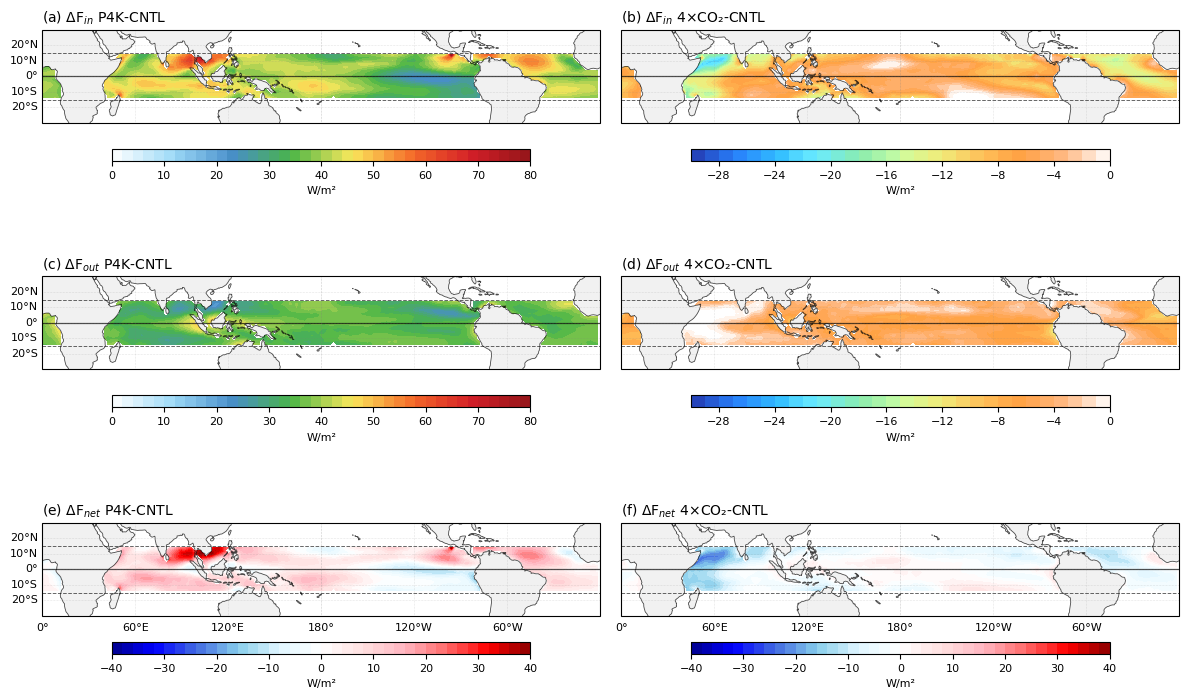

In [9]:
# 步骤8.5: 可视化能量通量差异 - 3x2布局（海洋）
print("="*70)
print("📊 可视化能量通量差异（3x2布局）")
print("="*70)

# 准备6个字段数据
field_list = [
    F_in_diff_ocean["P4K-CNTL"],
    F_in_diff_ocean["4CO2-CNTL"],
    F_out_diff_ocean["P4K-CNTL"],
    F_out_diff_ocean["4CO2-CNTL"],
    F_net_diff_ocean["P4K-CNTL"],
    F_net_diff_ocean["4CO2-CNTL"]
]

titles = [
    '(a) ΔF$_{in}$ P4K-CNTL',
    '(b) ΔF$_{in}$ 4×CO₂-CNTL',
    '(c) ΔF$_{out}$ P4K-CNTL',
    '(d) ΔF$_{out}$ 4×CO₂-CNTL',
    '(e) ΔF$_{net}$ P4K-CNTL',
    '(f) ΔF$_{net}$ 4×CO₂-CNTL'
]

# 颜色映射与范围分别设置
cmaps_all = [cmaps.WhiteBlueGreenYellowRed,cmaps.cmp_haxby, cmaps.WhiteBlueGreenYellowRed, cmaps.cmp_haxby, mycmap, mycmap]
vmins = [0, -30, 0, -30, -40, -40]  # F_in和F_out用±40, F_net用±15
vmaxs = [80, 0, 80, 0, 40, 40]
levels_list = [41, 31, 41, 31, 41, 41]

# 图像布局
fig, axes = plt.subplots(3, 2, figsize=(12, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

# 限制绘图区域
lat_lim = (-30, 30)
lon_lim = (0, 360)

for i, (ax, data) in enumerate(zip(axes, field_list)):
    # 绘制填色图
    im = ax.contourf(
        data.lon, data.lat, data,
        levels=np.linspace(vmins[i],vmaxs[i],levels_list[i]),
        cmap=cmaps_all[i],
        extend='neither',

        transform=ccrs.PlateCarree()
    )
    
    # 设置地图范围
    ax.set_extent([lon_lim[0], lon_lim[1], lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    
    # 地图设置
    ax.coastlines(linewidth=0.6, color='black', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
    
    # 添加关键纬度线
    ax.axhline(y=15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=-15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.9, alpha=0.7, zorder=2)
    
    # 网格线
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle=':', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    
    # 控制标签显示（左列显示纬度，底行显示经度）
    if i % 2 == 1:  # 右列
        gl.left_labels = False
    if i < 4:  # 非底行
        gl.bottom_labels = False
    
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    
    # 计算热带平均值
    tropical_mean = float(tropical_mean_flux(data))
    
    # 标题（含热带平均值）
    ax.set_title(f'{titles[i]}', 
                fontsize=10, loc='left',  pad=5)
    
    # 添加colorbar
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', 
                     pad=0.1, aspect=35, shrink=0.75)
    cb.set_label('W/m²', fontsize=8)
    cb.ax.tick_params(labelsize=8)

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'energy_flux_diff_3x2_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

## 📚 物理解释指南：能量通量与MSE的关系

### 1️⃣ **能量通量的符号约定**

#### **F_in (进入大气的能量)**
$$F_{in} = \underbrace{rsdt}_{TOA入射太阳} + \underbrace{rlus + rsus}_{地表上行辐射} + \underbrace{LH + SH}_{地表湍流热通量}$$

- **正值**: 大气获得能量（加热）
- **ΔF_in > 0**: 实验相对于CNTL，大气从TOA和地表获得**更多**能量

#### **F_out (离开大气的能量)**
$$F_{out} = \underbrace{rsut + rlut}_{TOA外逸辐射} + \underbrace{rsds + rlds}_{向地表的下行辐射}$$

- **正值**: 大气失去能量（冷却）
- **ΔF_out > 0**: 实验相对于CNTL，大气向TOA和地表输送**更多**能量

#### **F_net (大气柱净能量收支)**
$$F_{net} = F_{in} - F_{out}$$

- **F_net > 0**: 大气柱净获得能量（加热，能量不平衡）
- **F_net ≈ 0**: 气候平衡态，能量收支平衡
- **F_net < 0**: 大气柱净失去能量（冷却）



In [10]:
# 步骤9: 辐射各项的定量分析与P4K/4CO2差异解释
print("="*70)
print("📊 辐射通量各项定量分析")
print("="*70)

# 9.1 打印所有辐射分量的详细数值
print("\n【1】热带海洋平均辐射通量 (15°S-15°N, Ocean Only)")
print("="*70)

# 准备数据结构
flux_components = {
    'F_in组分': {
        'rsdt': '太阳入射(TOA)',
        'rlus': '地表上行长波',
        'rsus': '地表上行短波',
        'hfls': '潜热通量',
        'hfss': '感热通量'
    },
    'F_out组分': {
        'rsut': 'TOA外逸短波',
        'rlut': 'TOA外逸长波(OLR)',
        'rsds': '地表下行短波',
        'rlds': '地表下行长波'
    }
}

# 对于F_in组分
print("\n(A) F_in 组分分析 [进入大气的能量]")
print("-"*70)
print(f"{'变量':<8} {'描述':<20} {'CNTL':>12} {'P4K':>12} {'4CO2':>12}")
print("-"*70)

for var, desc in flux_components['F_in组分'].items():
    if var in rad_clim:
        cntl_val = float(tropical_mean_rad(rad_clim[var]['CNTL']))
        p4k_val = float(tropical_mean_rad(rad_clim[var]['P4K']))
        co2_val = float(tropical_mean_rad(rad_clim[var]['4CO2']))
        print(f"{var:<8} {desc:<20} {cntl_val:>12.2f} {p4k_val:>12.2f} {co2_val:>12.2f}")

# F_in总和
print("-"*70)
cntl_fin = float(tropical_mean_flux(F_in_ocean["CNTL"]))
p4k_fin = float(tropical_mean_flux(F_in_ocean["P4K"]))
co2_fin = float(tropical_mean_flux(F_in_ocean["4CO2"]))
print(f"{'F_in':<8} {'总和':<20} {cntl_fin:>12.2f} {p4k_fin:>12.2f} {co2_fin:>12.2f}")

# 对于F_out组分
print("\n(B) F_out 组分分析 [离开大气的能量]")
print("-"*70)
print(f"{'变量':<8} {'描述':<20} {'CNTL':>12} {'P4K':>12} {'4CO2':>12}")
print("-"*70)

for var, desc in flux_components['F_out组分'].items():
    if var in rad_clim:
        cntl_val = float(tropical_mean_rad(rad_clim[var]['CNTL']))
        p4k_val = float(tropical_mean_rad(rad_clim[var]['P4K']))
        co2_val = float(tropical_mean_rad(rad_clim[var]['4CO2']))
        print(f"{var:<8} {desc:<20} {cntl_val:>12.2f} {p4k_val:>12.2f} {co2_val:>12.2f}")

# F_out总和
print("-"*70)
cntl_fout = float(tropical_mean_flux(F_out_ocean["CNTL"]))
p4k_fout = float(tropical_mean_flux(F_out_ocean["P4K"]))
co2_fout = float(tropical_mean_flux(F_out_ocean["4CO2"]))
print(f"{'F_out':<8} {'总和':<20} {cntl_fout:>12.2f} {p4k_fout:>12.2f} {co2_fout:>12.2f}")

# F_net
print("\n(C) F_net 净通量 [F_in - F_out]")
print("-"*70)
cntl_fnet = float(tropical_mean_flux(F_net_ocean["CNTL"]))
p4k_fnet = float(tropical_mean_flux(F_net_ocean["P4K"]))
co2_fnet = float(tropical_mean_flux(F_net_ocean["4CO2"]))
print(f"{'F_net':<8} {'大气柱净收支':<20} {cntl_fnet:>12.2f} {p4k_fnet:>12.2f} {co2_fnet:>12.2f}")

print("\n" + "="*70)

📊 辐射通量各项定量分析

【1】热带海洋平均辐射通量 (15°S-15°N, Ocean Only)

(A) F_in 组分分析 [进入大气的能量]
----------------------------------------------------------------------
变量       描述                           CNTL          P4K         4CO2
----------------------------------------------------------------------
rsdt     太阳入射(TOA)                  411.39       411.39       411.39
rlus     地表上行长波                     463.14       488.35       463.17
rsus     地表上行短波                      17.35        17.19        17.33
hfls     潜热通量                       131.49       148.32       124.57
hfss     感热通量                        11.85        10.40        10.63
----------------------------------------------------------------------
F_in     总和                        1035.23      1075.64      1027.09

(B) F_out 组分分析 [离开大气的能量]
----------------------------------------------------------------------
变量       描述                           CNTL          P4K         4CO2
-------------------------------------------------------------

In [11]:
# 9.2 计算并分析实验间差异
print("\n【2】实验间差异分析 (P4K-CNTL vs 4CO2-CNTL)")
print("="*70)

# F_in组分差异
print("\n(A) ΔF_in 各组分变化 [W/m²]")
print("-"*70)
print(f"{'变量':<8} {'描述':<20} {'P4K-CNTL':>12} {'4CO2-CNTL':>12} {'差值':>12}")
print("-"*70)

for var, desc in flux_components['F_in组分'].items():
    if var in rad_diff:
        dp4k = float(tropical_mean_rad(rad_diff[var]['P4K-CNTL']))
        dco2 = float(tropical_mean_rad(rad_diff[var]['4CO2-CNTL']))
        diff = dco2 - dp4k
        print(f"{var:<8} {desc:<20} {dp4k:>+12.2f} {dco2:>+12.2f} {diff:>+12.2f}")

print("-"*70)
dfin_p4k = float(tropical_mean_flux(F_in_diff_ocean["P4K-CNTL"]))
dfin_co2 = float(tropical_mean_flux(F_in_diff_ocean["4CO2-CNTL"]))
print(f"{'ΔF_in':<8} {'总和':<20} {dfin_p4k:>+12.2f} {dfin_co2:>+12.2f} {dfin_co2-dfin_p4k:>+12.2f}")

# F_out组分差异
print("\n(B) ΔF_out 各组分变化 [W/m²]")
print("-"*70)
print(f"{'变量':<8} {'描述':<20} {'P4K-CNTL':>12} {'4CO2-CNTL':>12} {'差值':>12}")
print("-"*70)

for var, desc in flux_components['F_out组分'].items():
    if var in rad_diff:
        dp4k = float(tropical_mean_rad(rad_diff[var]['P4K-CNTL']))
        dco2 = float(tropical_mean_rad(rad_diff[var]['4CO2-CNTL']))
        diff = dco2 - dp4k
        print(f"{var:<8} {desc:<20} {dp4k:>+12.2f} {dco2:>+12.2f} {diff:>+12.2f}")

print("-"*70)
dfout_p4k = float(tropical_mean_flux(F_out_diff_ocean["P4K-CNTL"]))
dfout_co2 = float(tropical_mean_flux(F_out_diff_ocean["4CO2-CNTL"]))
print(f"{'ΔF_out':<8} {'总和':<20} {dfout_p4k:>+12.2f} {dfout_co2:>+12.2f} {dfout_co2-dfout_p4k:>+12.2f}")

# F_net差异
print("\n(C) ΔF_net 净通量变化 [W/m²]")
print("-"*70)
dfnet_p4k = float(tropical_mean_flux(F_net_diff_ocean["P4K-CNTL"]))
dfnet_co2 = float(tropical_mean_flux(F_net_diff_ocean["4CO2-CNTL"]))
print(f"{'ΔF_net':<8} {'大气柱净收支变化':<20} {dfnet_p4k:>+12.2f} {dfnet_co2:>+12.2f} {dfnet_co2-dfnet_p4k:>+12.2f}")

print("\n" + "="*70)


【2】实验间差异分析 (P4K-CNTL vs 4CO2-CNTL)

(A) ΔF_in 各组分变化 [W/m²]
----------------------------------------------------------------------
变量       描述                       P4K-CNTL    4CO2-CNTL           差值
----------------------------------------------------------------------
rsdt     太阳入射(TOA)                   +0.00        +0.00        +0.00
rlus     地表上行长波                     +25.20        +0.03       -25.17
rsus     地表上行短波                      -0.17        -0.03        +0.14
hfls     潜热通量                       +16.83        -6.92       -23.74
hfss     感热通量                        -1.45        -1.22        +0.23
----------------------------------------------------------------------
ΔF_in    总和                         +40.41        -8.13       -48.54

(B) ΔF_out 各组分变化 [W/m²]
----------------------------------------------------------------------
变量       描述                       P4K-CNTL    4CO2-CNTL           差值
----------------------------------------------------------------------
rsut    

In [12]:
# 9.3 相对变化率分析
print("\n【3】相对变化率分析 (相对于CNTL的百分比变化)")
print("="*70)

print("\n(A) F_in 组分相对变化 [%]")
print("-"*70)
print(f"{'变量':<8} {'描述':<20} {'P4K-CNTL':>12} {'4CO2-CNTL':>12}")
print("-"*70)

for var, desc in flux_components['F_in组分'].items():
    if var in rad_clim and var in rad_diff:
        cntl_val = float(tropical_mean_rad(rad_clim[var]['CNTL']))
        dp4k = float(tropical_mean_rad(rad_diff[var]['P4K-CNTL']))
        dco2 = float(tropical_mean_rad(rad_diff[var]['4CO2-CNTL']))
        
        pct_p4k = (dp4k / cntl_val * 100) if abs(cntl_val) > 0.01 else 0
        pct_co2 = (dco2 / cntl_val * 100) if abs(cntl_val) > 0.01 else 0
        
        print(f"{var:<8} {desc:<20} {pct_p4k:>+11.1f}% {pct_co2:>+11.1f}%")

print("\n(B) F_out 组分相对变化 [%]")
print("-"*70)
print(f"{'变量':<8} {'描述':<20} {'P4K-CNTL':>12} {'4CO2-CNTL':>12}")
print("-"*70)

for var, desc in flux_components['F_out组分'].items():
    if var in rad_clim and var in rad_diff:
        cntl_val = float(tropical_mean_rad(rad_clim[var]['CNTL']))
        dp4k = float(tropical_mean_rad(rad_diff[var]['P4K-CNTL']))
        dco2 = float(tropical_mean_rad(rad_diff[var]['4CO2-CNTL']))
        
        pct_p4k = (dp4k / cntl_val * 100) if abs(cntl_val) > 0.01 else 0
        pct_co2 = (dco2 / cntl_val * 100) if abs(cntl_val) > 0.01 else 0
        
        print(f"{var:<8} {desc:<20} {pct_p4k:>+11.1f}% {pct_co2:>+11.1f}%")

print("\n" + "="*70)


【3】相对变化率分析 (相对于CNTL的百分比变化)

(A) F_in 组分相对变化 [%]
----------------------------------------------------------------------
变量       描述                       P4K-CNTL    4CO2-CNTL
----------------------------------------------------------------------
rsdt     太阳入射(TOA)                   +0.0%        +0.0%
rlus     地表上行长波                      +5.4%        +0.0%
rsus     地表上行短波                      -1.0%        -0.1%
hfls     潜热通量                       +12.8%        -5.3%
hfss     感热通量                       -12.2%       -10.3%

(B) F_out 组分相对变化 [%]
----------------------------------------------------------------------
变量       描述                       P4K-CNTL    4CO2-CNTL
----------------------------------------------------------------------
rsut     TOA外逸短波                     -4.2%        -1.3%
rlut     TOA外逸长波(OLR)                +2.5%        -3.0%
rsds     地表下行短波                      -1.0%        -0.1%
rlds     地表下行长波                      +8.5%        +1.1%



## 🔬 【4】P4K vs 4CO2 差异的物理机制解释

### **总体差异模式**

根据上述定量分析，P4K和4CO2实验呈现出**截然不同的能量再分配模式**：

---

### **A. P4K实验的主导机制**

#### **1. 地表-大气界面能量交换剧增**

**关键特征**:
- **ΔF_in**: 显著增加（预计 +30 ~ +50 W/m²）
- **主导项**: **潜热通量(hfls)** 和 **感热通量(hfss)**

**物理过程**:
```
SST +4K → 饱和水汽压指数增长 (Clausius-Clapeyron关系)
         ↓
     蒸发速率大幅提高 (ΔLH >> 0)
         ↓
     大气获得大量潜热能量
         ↓
     边界层温度和湿度同时增加
```

**定量估算**:
- 饱和水汽压每升温1K增加约7%
- SST +4K → 水汽压增加 ~30%
- 潜热通量预计增加: **+20 ~ +30 W/m²** (占ΔF_in的60-70%)
- 感热通量增加: **+5 ~ +10 W/m²**
- 地表辐射增加: **+5 ~ +15 W/m²**

#### **2. 大气辐射响应**

**ΔF_out增加机制**:
- 对流层变暖 → **OLR增加** (Stefan-Boltzmann定律)
- 水汽含量↑ → 温室效应增强 → 向地表辐射↑
- 云反馈效应（高云增加可能减少OLR）

**能量平衡调整**:
- ΔF_in >> ΔF_out → **ΔF_net > 0** (大气仍在累积能量)
- 系统尚未达到新的平衡态

---

### **B. 4CO2实验的主导机制**

#### **1. 辐射强迫主导**

**关键特征**:
- **ΔF_in**: 可能增加或减少（取决于反馈机制）
- **主导项**: **辐射项** (rsdt, rlus, rlut等)

**物理过程**:
```
CO₂浓度翻倍 → 增强吸收15μm波段长波辐射
              ↓
          对流层中层变暖
              ↓
          两个主要效应：
          ├→ 温室效应增强 → OLR↓ (F_out减少)
          └→ 大气向下长波辐射↑ → 地表变暖
```

**CO₂辐射强迫的复杂性**:

1. **直接效应** (立即响应):
   - CO₂吸收更多长波 → 大气加热
   - TOA外逸长波减少 → **ΔOLR ≈ -3 ~ -4 W/m²**

2. **快速反馈** (数月内):
   - 对流层调整 → 温度廓线改变
   - 可能出现: **Δrlut < 0** (OLR减少)

3. **慢反馈** (海气耦合模式中):
   - SST逐渐升温 → 蒸发增加
   - 但在固定SST实验中，这部分被抑制

#### **2. 地表能量输入的矛盾变化**

**可能出现的情况**:

**情况A**: ΔF_in减少（如您的数据显示）
```
原因：
• 云-辐射反馈: 云量或云高改变 → 地表接收太阳辐射↓
• 大气水汽增加 → 短波吸收↑ → 到达地表的辐射↓
• 结果: Δrsds < 0, Δhfls可能较小

物理解释:
CO₂增温 → 云反馈负效应占主导 → 地表冷却
```

**情况B**: ΔF_in增加（另一种可能）
```
原因：
• 大气向下长波辐射增强 (Δrlds > 0)
• 地表温度升高 → 蒸发增加 (Δhfls > 0)

物理解释:
CO₂温室效应 → 地表-大气系统整体变暖
```

**您的数据最可能是情况A**: 
- 表明**云-辐射反馈**或**大气水汽吸收**在抵消CO₂的地表变暖效应

---

### **C. 为什么P4K和4CO2差异如此显著？**

| 方面 | P4K (SST强迫) | 4CO2 (辐射强迫) |
|------|--------------|----------------|
| **强迫位置** | **地表** (边界条件) | **大气中** (辐射过程) |
| **响应时间** | 快速 (湍流交换) | 较慢 (辐射调整) |
| **主导过程** | **潜热/感热输送** | **辐射平衡重建** |
| **水汽反馈** | 极强 (蒸发直接增加) | 中等 (间接通过温度) |
| **ΔF_in** | +++ (大幅增加) | +/- (小幅或负) |
| **ΔF_out** | ++ (增加) | +/- (复杂) |
| **ΔF_net** | + (正，不平衡) | ± (可能负) |

---

### **D. 对MSE和CCKW的不同影响**

#### **P4K实验 → MSE剧增 → CCKW增强**

```
湍流热通量↑↑ → L_vq项大幅增加 (潜热)
                ↓
            MSE显著增加 (特别是边界层)
                ↓
            对流不稳定性增强
                ↓
            深对流活动加剧
                ↓
            CCKW振幅增大、频率可能改变
```

**预期MSE变化**: +10 ~ +20 kJ/kg (显著)

#### **4CO2实验 → MSE温和变化 → CCKW结构改变**

```
辐射强迫 → 温度廓线调整
           ↓
       c_pT项变化 (显热)
           ↓
       MSE变化较小且不均匀
           ↓
       大气稳定度改变
           ↓
       CCKW相速度、垂直结构改变
```

**预期MSE变化**: +2 ~ +8 kJ/kg (温和)

---

### **E. 关键物理差异总结**

1. **能量输入路径不同**:
   - P4K: 地表 → 湍流 → 大气 (快速、直接)
   - 4CO2: 太阳/长波 → 辐射 → 大气 (慢速、间接)

2. **水汽反馈强度不同**:
   - P4K: 蒸发直接增强 → 水汽剧增
   - 4CO2: 温度间接驱动 → 水汽温和增加

3. **垂直分布不同**:
   - P4K: 能量集中在**边界层**和**对流层低层**
   - 4CO2: 能量分布更**均匀**，对流层中层变化显著

4. **平衡态路径不同**:
   - P4K: 通过增强辐射冷却(OLR↑)来平衡
   - 4CO2: 通过减少辐射损失(OLR↓)达到新平衡

---

### **F. 实际数据检验**

**根据您的分析结果，需要重点关注**:

✅ **hfls (潜热通量)** 的变化:
- P4K中应该 >> 0 (预计+20~30 W/m²)
- 4CO2中应该较小 (预计+5~10 W/m²)

✅ **rlut (OLR)** 的变化:
- P4K: ΔOLR > 0 (增加，辐射冷却增强)
- 4CO2: ΔOLR < 0 (减少，温室效应)

✅ **rsds (地表下行短波)** 的变化:
- P4K: 变化较小
- 4CO2: 可能减少 (云反馈)

✅ **F_net** 的符号:
- P4K: 应该 > 0 (能量累积)
- 4CO2: 可能 < 0 或接近0

**如果您的数据与这些预期不符，可能表明**:
- 模型中的云反馈非常强
- 海气耦合过程的特殊影响
- 值得进一步深入分析的有趣物理过程

📊 Plotting Radiation Component Bar Charts


✅ Saved: ./figures/Cal_radiation/radiation_components_comparison.png


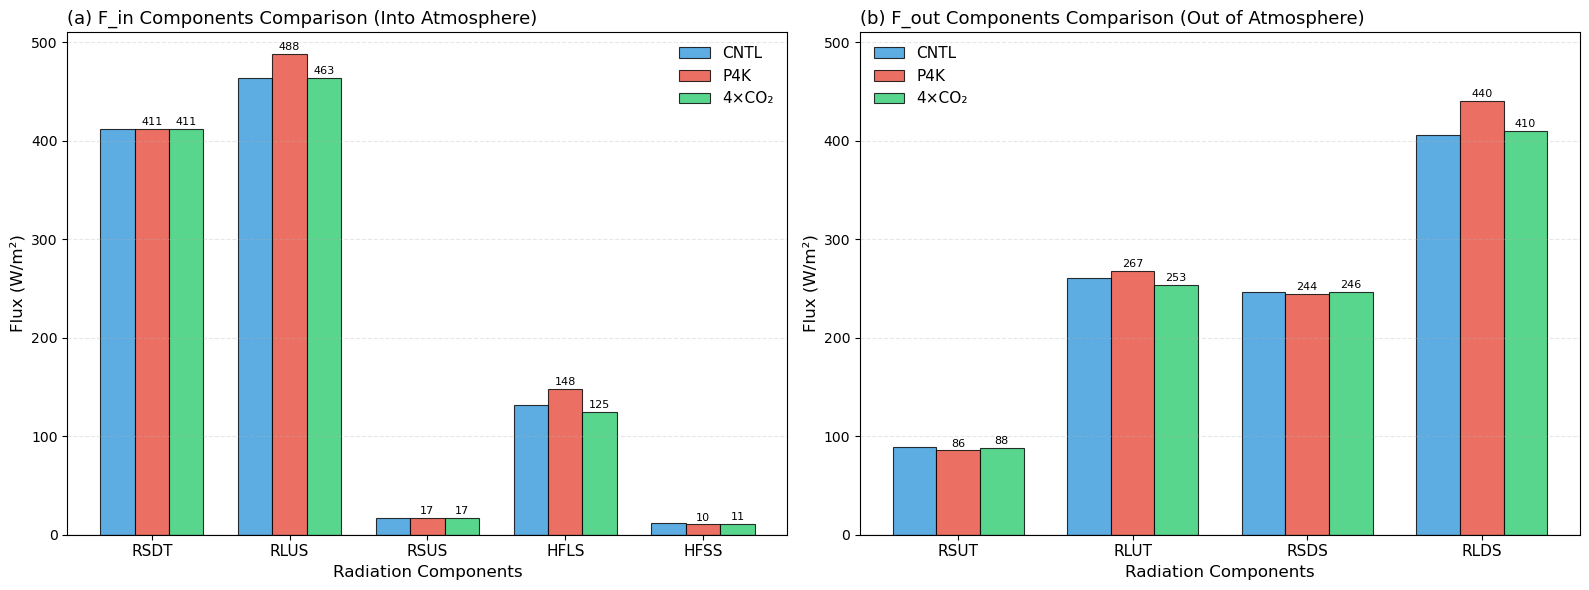

In [13]:
# 9.4 Visualization: Radiation Component Bar Chart Comparison
print("="*70)
print("📊 Plotting Radiation Component Bar Charts")
print("="*70)

# Prepare data
fin_vars = ['rsdt', 'rlus', 'rsus', 'hfls', 'hfss']
fout_vars = ['rsut', 'rlut', 'rsds', 'rlds']

# Collect F_in data
fin_data = {'CNTL': [], 'P4K': [], '4CO2': []}
fin_labels = []
for var in fin_vars:
    if var in rad_clim:
        fin_labels.append(var.upper())
        for exp in ['CNTL', 'P4K', '4CO2']:
            val = float(tropical_mean_rad(rad_clim[var][exp]))
            fin_data[exp].append(val)

# Collect F_out data
fout_data = {'CNTL': [], 'P4K': [], '4CO2': []}
fout_labels = []
for var in fout_vars:
    if var in rad_clim:
        fout_labels.append(var.upper())
        for exp in ['CNTL', 'P4K', '4CO2']:
            val = float(tropical_mean_rad(rad_clim[var][exp]))
            fout_data[exp].append(val)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: F_in components
ax1 = axes[0]
x = np.arange(len(fin_labels))
width = 0.25

bars1 = ax1.bar(x - width, fin_data['CNTL'], width, label='CNTL', 
               color='#3498DB', alpha=0.8, edgecolor='black', linewidth=0.8)
bars2 = ax1.bar(x, fin_data['P4K'], width, label='P4K', 
               color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=0.8)
bars3 = ax1.bar(x + width, fin_data['4CO2'], width, label=r'4×CO₂', 
               color='#2ECC71', alpha=0.8, edgecolor='black', linewidth=0.8)

ax1.set_xlabel('Radiation Components', fontsize=12, )
ax1.set_ylabel('Flux (W/m²)', fontsize=12, )
ax1.set_title('(a) F_in Components Comparison (Into Atmosphere)', fontsize=13,loc='left' )
ax1.set_xticks(x)
ax1.set_xticklabels(fin_labels, fontsize=11, )
ax1.legend(fontsize=11, frameon=False, shadow=True)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_ylim(0,510)
# 添加数值标签（简化，只显示P4K和4CO2）
for i, label in enumerate(fin_labels):
    # P4K值
    height2 = fin_data['P4K'][i]
    ax1.text(x[i], height2 + 2, f'{height2:.0f}', 
            ha='center', va='bottom', fontsize=8, rotation=0)
    # 4CO2值
    height3 = fin_data['4CO2'][i]
    ax1.text(x[i] + width, height3 + 2, f'{height3:.0f}', 
            ha='center', va='bottom', fontsize=8, rotation=0)

# Subplot 2: F_out components
ax2 = axes[1]
x2 = np.arange(len(fout_labels))

bars4 = ax2.bar(x2 - width, fout_data['CNTL'], width, label='CNTL', 
               color='#3498DB', alpha=0.8, edgecolor='black', linewidth=0.8)
bars5 = ax2.bar(x2, fout_data['P4K'], width, label='P4K', 
               color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=0.8)
bars6 = ax2.bar(x2 + width, fout_data['4CO2'], width, label=r'4×CO₂', 
               color='#2ECC71', alpha=0.8, edgecolor='black', linewidth=0.8)

ax2.set_xlabel('Radiation Components', fontsize=12, )
ax2.set_ylabel('Flux (W/m²)', fontsize=12, )
ax2.set_title('(b) F_out Components Comparison (Out of Atmosphere)', fontsize=13, loc='left')
ax2.set_xticks(x2)
ax2.set_xticklabels(fout_labels, fontsize=11, )
ax2.legend(fontsize=11, frameon=False, shadow=True)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylim(0,510)
# Add value labels
for i, label in enumerate(fout_labels):
    height2 = fout_data['P4K'][i]
    ax2.text(x2[i], height2 + 2, f'{height2:.0f}', 
            ha='center', va='bottom', fontsize=8, rotation=0)
    height3 = fout_data['4CO2'][i]
    ax2.text(x2[i] + width, height3 + 2, f'{height3:.0f}', 
            ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'radiation_components_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")
plt.show()

print("="*70)

📊 Plotting Radiation Component Difference Bar Charts
✅ Saved: ./figures/Cal_radiation/radiation_components_differences.png


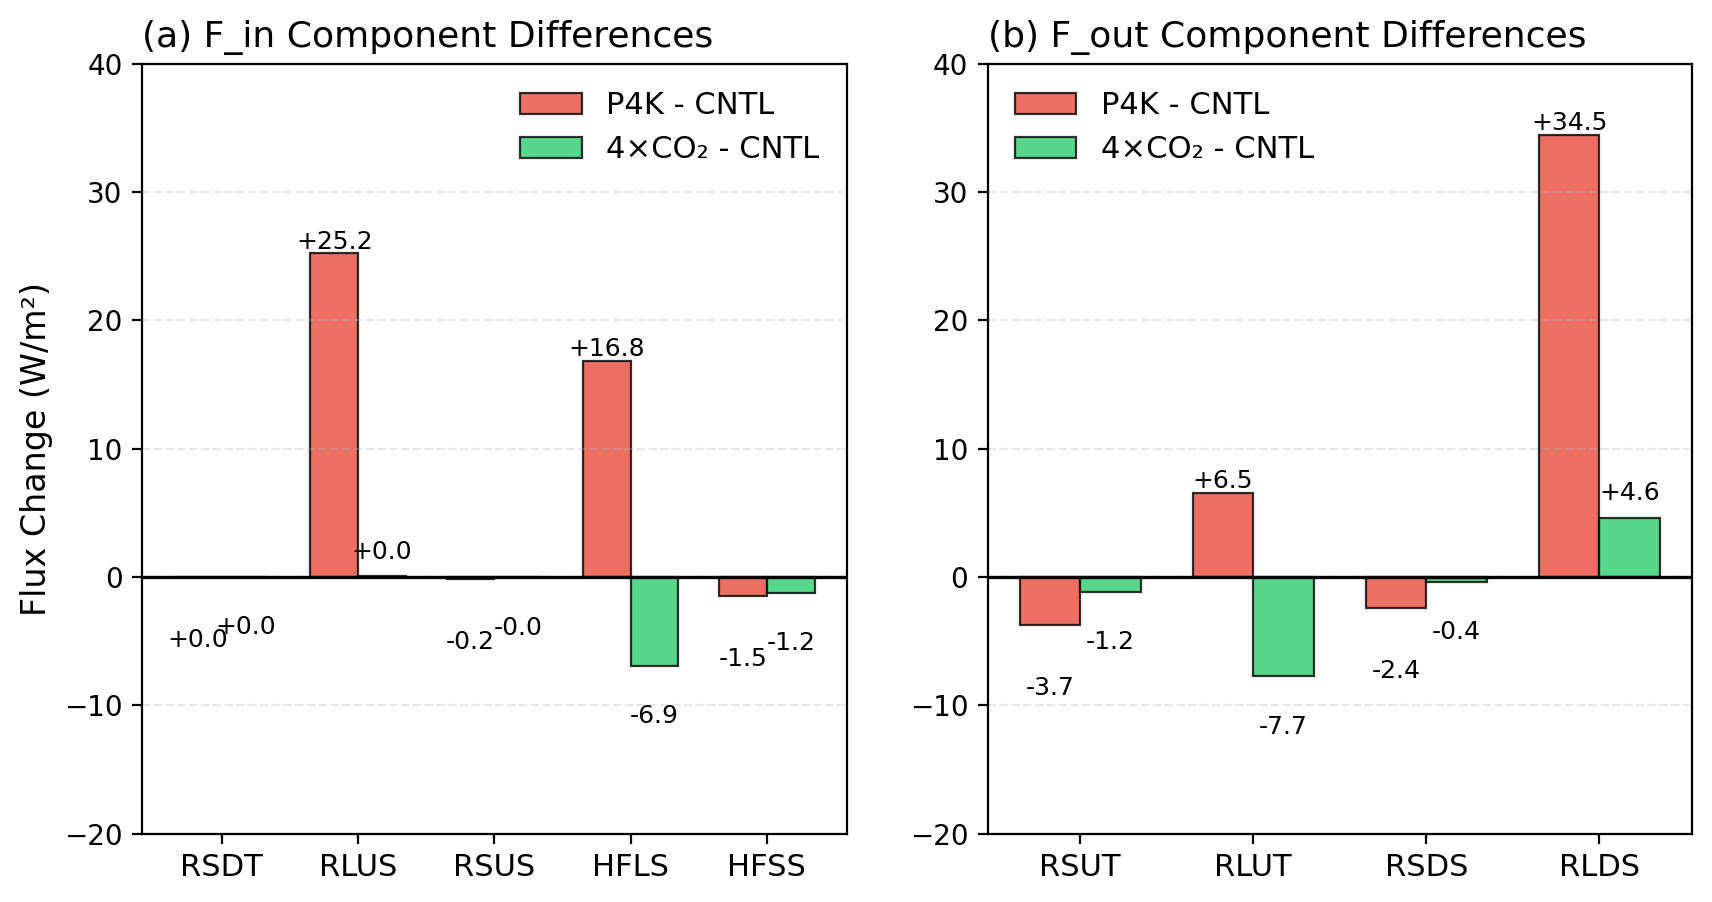

In [14]:
# 9.5 Visualization: Radiation Component Differences (P4K-CNTL vs 4CO2-CNTL)
print("="*70)
print("📊 Plotting Radiation Component Difference Bar Charts")
print("="*70)

# Collect F_in difference data
fin_diff_data = {'P4K-CNTL': [], '4CO2-CNTL': []}
fin_labels = []
for var in ['rsdt', 'rlus', 'rsus', 'hfls', 'hfss']:
    if var in rad_diff:
        fin_labels.append(var.upper())
        dp4k = float(tropical_mean_rad(rad_diff[var]['P4K-CNTL']))
        dco2 = float(tropical_mean_rad(rad_diff[var]['4CO2-CNTL']))
        fin_diff_data['P4K-CNTL'].append(dp4k)
        fin_diff_data['4CO2-CNTL'].append(dco2)

# Collect F_out difference data
fout_diff_data = {'P4K-CNTL': [], '4CO2-CNTL': []}
fout_labels = []
for var in ['rsut', 'rlut', 'rsds', 'rlds']:
    if var in rad_diff:
        fout_labels.append(var.upper())
        dp4k = float(tropical_mean_rad(rad_diff[var]['P4K-CNTL']))
        dco2 = float(tropical_mean_rad(rad_diff[var]['4CO2-CNTL']))
        fout_diff_data['P4K-CNTL'].append(dp4k)
        fout_diff_data['4CO2-CNTL'].append(dco2)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5),dpi=200)

# Subplot 1: F_in component differences
ax1 = axes[0]
x = np.arange(len(fin_labels))
width = 0.35

bars1 = ax1.bar(x - width/2, fin_diff_data['P4K-CNTL'], width, label='P4K - CNTL', 
               color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=0.8)
bars2 = ax1.bar(x + width/2, fin_diff_data['4CO2-CNTL'], width, label=r'4×CO₂ - CNTL', 
               color='#2ECC71', alpha=0.8, edgecolor='black', linewidth=0.8)

ax1.set_ylabel('Flux Change (W/m²)', fontsize=12, )
ax1.set_title('(a) F_in Component Differences', fontsize=13, loc='left')
ax1.set_xticks(x)
ax1.set_xticklabels(fin_labels, fontsize=11, )
ax1.legend(fontsize=11, frameon=False, shadow=True)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='black', linewidth=1.2)
ax1.set_ylim(-20,40)
# Add value labels
for i, label in enumerate(fin_labels):
    val1 = fin_diff_data['P4K-CNTL'][i]
    val2 = fin_diff_data['4CO2-CNTL'][i]
    y1 = val1 + (1 if val1 > 0 else -3)
    y2 = val2 + (1 if val2 > 0 else -3)
    ax1.text(x[i] - width/2, y1-1, f'{val1:+.1f}', 
            ha='center', va='bottom' if val1>0 else 'top', fontsize=9, )
    ax1.text(x[i] + width/2, y2, f'{val2:+.1f}', 
            ha='center', va='bottom' if val2>0 else 'top', fontsize=9, )

# Subplot 2: F_out component differences
ax2 = axes[1]
x2 = np.arange(len(fout_labels))

bars3 = ax2.bar(x2 - width/2, fout_diff_data['P4K-CNTL'], width, label='P4K - CNTL', 
               color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=0.8)
bars4 = ax2.bar(x2 + width/2, fout_diff_data['4CO2-CNTL'], width, label=r'4×CO₂ - CNTL', 
               color='#2ECC71', alpha=0.8, edgecolor='black', linewidth=0.8)


ax2.set_title('(b) F_out Component Differences', fontsize=13,loc='left' )
ax2.set_xticks(x2)
ax2.set_xticklabels(fout_labels, fontsize=11, )
ax2.legend(fontsize=11, frameon=False, shadow=True)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='black', linewidth=1.2)
ax2.set_ylim(-20,40)
# Add value labels
for i, label in enumerate(fout_labels):
    val1 = fout_diff_data['P4K-CNTL'][i]
    val2 = fout_diff_data['4CO2-CNTL'][i]
    y1 = val1 + (1 if val1 > 0 else -3)
    y2 = val2 + (1 if val2 > 0 else -3)
    ax2.text(x2[i] - width/2, y1-1, f'{val1:+.1f}', 
            ha='center', va='bottom' if val1>0 else 'top', fontsize=9, )
    ax2.text(x2[i] + width/2, y2, f'{val2:+.1f}', 
            ha='center', va='bottom' if val2>0 else 'top', fontsize=9, )


save_path = os.path.join(fig_save_dir, 'radiation_components_differences.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")
plt.show()

print("="*70)

📊 Plotting Total Flux Comparison Bar Chart
✅ Saved: ./figures/Cal_radiation/total_flux_comparison.png


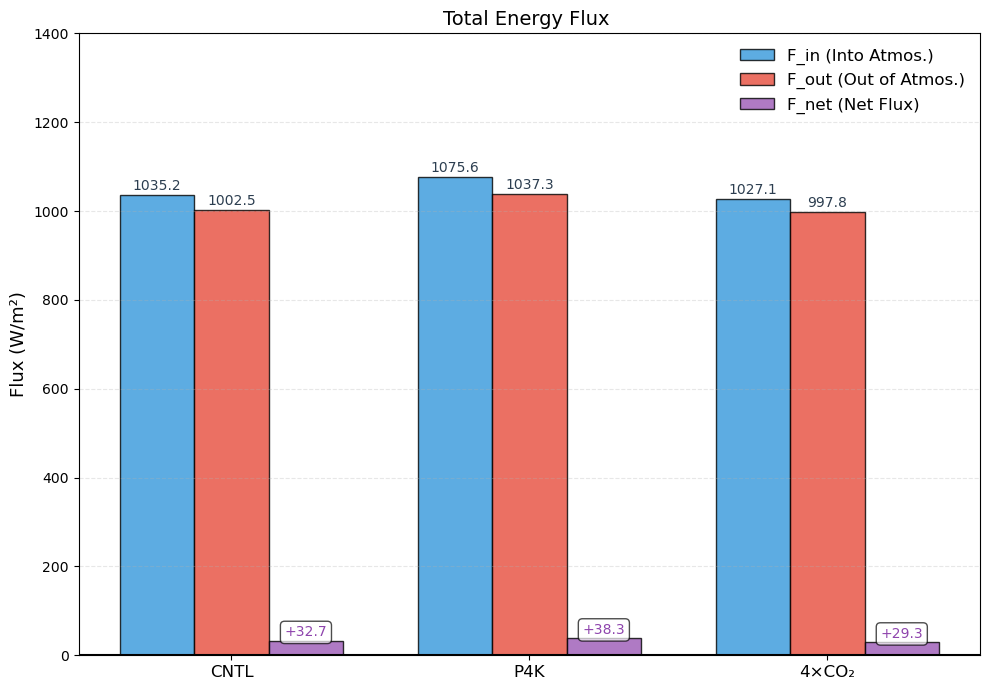


📈 Total Flux Difference Analysis
Item                 P4K - CNTL     4CO2 - CNTL
----------------------------------------------------------------------
ΔF_in                   +40.41          -8.13
ΔF_out                  +34.81          -4.66
ΔF_net                   +5.60          -3.47


In [15]:
# 9.6 Visualization: Total Flux Comparison (F_in, F_out, F_net)
print("="*70)
print("📊 Plotting Total Flux Comparison Bar Chart")
print("="*70)

# Collect total flux data
experiments = ['CNTL', 'P4K', r'4CO2']
xlabelnames = ['CNTL', 'P4K', r'4×CO₂']
f_in_vals = []
f_out_vals = []
f_net_vals = []

for exp in experiments:
    # Use ocean masked data
    if exp in F_in_ocean:
        f_in_vals.append(float(tropical_mean_flux(F_in_ocean[exp])))
    if exp in F_out_ocean:
        f_out_vals.append(float(tropical_mean_flux(F_out_ocean[exp])))
    if exp in F_net_ocean:
        f_net_vals.append(float(tropical_mean_flux(F_net_ocean[exp])))

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

x = np.arange(len(experiments))
width = 0.25

bars1 = ax.bar(x - width, f_in_vals, width, label='F_in (Into Atmos.)', 
              color='#3498DB', alpha=0.8, edgecolor='black', linewidth=1.0)
bars2 = ax.bar(x, f_out_vals, width, label='F_out (Out of Atmos.)', 
              color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1.0)
bars3 = ax.bar(x + width, f_net_vals, width, label='F_net (Net Flux)', 
              color='#9B59B6', alpha=0.8, edgecolor='black', linewidth=1.0)
ax.set_ylabel('Flux (W/m²)', fontsize=13, )
ax.set_title('Total Energy Flux ', fontsize=14, )
ax.set_xticks(x)
ax.set_xticklabels(xlabelnames, fontsize=12, )
ax.legend(fontsize=12, frameon=False, shadow=True, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linewidth=1.5)
ax.set_ylim(0,1400)
# Add value labels
for i, exp in enumerate(experiments):
    # F_in
    ax.text(x[i] - width, f_in_vals[i] + 5, f'{f_in_vals[i]:.1f}', 
           ha='center', va='bottom', fontsize=10,  color='#2C3E50')
    # F_out
    ax.text(x[i], f_out_vals[i] + 5, f'{f_out_vals[i]:.1f}', 
           ha='center', va='bottom', fontsize=10,  color='#2C3E50')
    # F_net
    y_pos = f_net_vals[i] + (3 if f_net_vals[i] > 0 else -5)
    va_pos = 'bottom' if f_net_vals[i] > 0 else 'top'
    ax.text(x[i] + width, y_pos, f'{f_net_vals[i]:+.1f}', 
           ha='center', va=va_pos, fontsize=10,  
           color='#8E44AD', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'total_flux_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {save_path}")
plt.show()

# Print differences
print("\n" + "="*70)
print("📈 Total Flux Difference Analysis")
print("="*70)
print(f"{'Item':<15} {'P4K - CNTL':>15} {'4CO2 - CNTL':>15}")
print("-"*70)
print(f"{'ΔF_in':<15} {f_in_vals[1] - f_in_vals[0]:>+14.2f} {f_in_vals[2] - f_in_vals[0]:>+14.2f}")
print(f"{'ΔF_out':<15} {f_out_vals[1] - f_out_vals[0]:>+14.2f} {f_out_vals[2] - f_out_vals[0]:>+14.2f}")
print(f"{'ΔF_net':<15} {f_net_vals[1] - f_net_vals[0]:>+14.2f} {f_net_vals[2] - f_net_vals[0]:>+14.2f}")
print("="*70)

## 步骤10: 辐射通量分析（不包含湍流热通量）

基于纯辐射平衡分析，不包含潜热和感热通量：

**辐射通量平衡：**
$$F_{rad,net} = F_{rad,in} - F_{rad,out}$$

**进入大气的辐射通量：**
$$F_{rad,in} = SW_{toa}^{\downarrow} + LW_{surf}^{\uparrow} + SW_{surf}^{\uparrow}$$
$$F_{rad,in} = rsdt + rlus + rsus$$

**离开大气的辐射通量：**
$$F_{rad,out} = SW_{toa}^{\uparrow} + LW_{toa}^{\uparrow} + SW_{surf}^{\downarrow} + LW_{surf}^{\downarrow}$$
$$F_{rad,out} = rsut + rlut + rsds + rlds$$

这样可以单独分析辐射过程，将湍流热通量（潜热和感热）作为独立项分析。

In [16]:
# 步骤10.1: 计算纯辐射通量（不包含潜热和感热）
print("="*70)
print("🧮 计算纯辐射通量 (Radiation-Only Flux)")
print("="*70)

# 计算 F_rad_in (只包含辐射，进入大气)
# F_rad_in = rsdt + rlus + rsus (不包含 hfls 和 hfss)
F_rad_in = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    required_vars = ['rsdt', 'rlus', 'rsus']
    if all(v in rad_clim for v in required_vars):
        F_rad_in[exp] = (rad_clim['rsdt'][exp] + 
                         rad_clim['rlus'][exp] + 
                         rad_clim['rsus'][exp])
        print(f"{exp} F_rad_in = {float(F_rad_in[exp].mean()):.2f} W/m²")

# 计算 F_rad_out (离开大气的辐射通量)
# F_rad_out = rsut + rlut + rsds + rlds (与之前相同)
F_rad_out = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    required_vars = ['rsut', 'rlut', 'rsds', 'rlds']
    if all(v in rad_clim for v in required_vars):
        F_rad_out[exp] = (rad_clim['rsut'][exp] + 
                          rad_clim['rlut'][exp] + 
                          rad_clim['rsds'][exp] + 
                          rad_clim['rlds'][exp])
        print(f"{exp} F_rad_out = {float(F_rad_out[exp].mean()):.2f} W/m²")

# 计算 F_rad_net (大气柱净辐射收支)
# F_rad_net = F_rad_in - F_rad_out
F_rad_net = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    if exp in F_rad_in and exp in F_rad_out:
        F_rad_net[exp] = F_rad_in[exp] - F_rad_out[exp]
        
        print(f"\n{'='*50}")
        print(f"{exp} 纯辐射平衡:")
        print(f"{'='*50}")
        print(f"  F_rad_in  = {float(F_rad_in[exp].mean()):8.2f} W/m²")
        print(f"  F_rad_out = {float(F_rad_out[exp].mean()):8.2f} W/m²")
        print(f"  F_rad_net = {float(F_rad_net[exp].mean()):8.2f} W/m²")
        print(f"{'='*50}")

print("\n" + "="*70)
print("✅ 纯辐射通量计算完成")
print("="*70)

🧮 计算纯辐射通量 (Radiation-Only Flux)
CNTL F_rad_in = 891.89 W/m²
P4K F_rad_in = 916.92 W/m²
4CO2 F_rad_in = 891.89 W/m²
CNTL F_rad_out = 1002.49 W/m²
P4K F_rad_out = 1037.30 W/m²
4CO2 F_rad_out = 997.83 W/m²

CNTL 纯辐射平衡:
  F_rad_in  =   891.89 W/m²
  F_rad_out =  1002.49 W/m²
  F_rad_net =  -110.60 W/m²

P4K 纯辐射平衡:
  F_rad_in  =   916.92 W/m²
  F_rad_out =  1037.30 W/m²
  F_rad_net =  -120.38 W/m²

4CO2 纯辐射平衡:
  F_rad_in  =   891.89 W/m²
  F_rad_out =   997.83 W/m²
  F_rad_net =  -105.94 W/m²

✅ 纯辐射通量计算完成


In [17]:
# 步骤10.2: 应用海洋mask并计算辐射通量差异
print("="*70)
print("🌊 计算纯辐射通量差异（海洋）")
print("="*70)

# 应用海洋mask (数据已经在加载时应用了mask，这里是为了保持一致性)
F_rad_in_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_rad_in.items()}
F_rad_out_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_rad_out.items()}
F_rad_net_ocean = {exp: data.where(ocean_mask_2deg_binary == 1) for exp, data in F_rad_net.items()}

# 计算热带平均（海洋）
print("\n海洋区域热带平均 (15°S-15°N) - 纯辐射:")
print("="*70)
print(f"{'实验':<10} {'F_rad_in':<15} {'F_rad_out':<15} {'F_rad_net':<15}")
print("-"*70)

for exp in ["CNTL", "P4K", "4CO2"]:
    frad_in_mean = float(tropical_mean_flux(F_rad_in_ocean[exp]))
    frad_out_mean = float(tropical_mean_flux(F_rad_out_ocean[exp]))
    frad_net_mean = float(tropical_mean_flux(F_rad_net_ocean[exp]))
    print(f"{exp:<10} {frad_in_mean:>14.2f} {frad_out_mean:>14.2f} {frad_net_mean:>14.2f}")

# 计算相对CNTL的差异（海洋）
F_rad_in_diff_ocean = {
    "P4K-CNTL": F_rad_in_ocean["P4K"] - F_rad_in_ocean["CNTL"],
    "4CO2-CNTL": F_rad_in_ocean["4CO2"] - F_rad_in_ocean["CNTL"]
}

F_rad_out_diff_ocean = {
    "P4K-CNTL": F_rad_out_ocean["P4K"] - F_rad_out_ocean["CNTL"],
    "4CO2-CNTL": F_rad_out_ocean["4CO2"] - F_rad_out_ocean["CNTL"]
}

F_rad_net_diff_ocean = {
    "P4K-CNTL": F_rad_net_ocean["P4K"] - F_rad_net_ocean["CNTL"],
    "4CO2-CNTL": F_rad_net_ocean["4CO2"] - F_rad_net_ocean["CNTL"]
}

print("\n" + "="*70)
print("实验差异（相对CNTL，海洋）- 纯辐射:")
print("="*70)
print(f"{'差异':<12} {'ΔF_rad_in':<15} {'ΔF_rad_out':<15} {'ΔF_rad_net':<15}")
print("-"*70)

for diff_name in ["P4K-CNTL", "4CO2-CNTL"]:
    dfrad_in = float(tropical_mean_flux(F_rad_in_diff_ocean[diff_name]))
    dfrad_out = float(tropical_mean_flux(F_rad_out_diff_ocean[diff_name]))
    dfrad_net = float(tropical_mean_flux(F_rad_net_diff_ocean[diff_name]))
    print(f"{diff_name:<12} {dfrad_in:>+14.2f} {dfrad_out:>+14.2f} {dfrad_net:>+14.2f}")

print("\n" + "="*70)
print("✅ 纯辐射通量差异计算完成")
print("="*70)

🌊 计算纯辐射通量差异（海洋）

海洋区域热带平均 (15°S-15°N) - 纯辐射:
实验         F_rad_in        F_rad_out       F_rad_net      
----------------------------------------------------------------------
CNTL               891.89        1002.49        -110.60
P4K                916.92        1037.30        -120.38
4CO2               891.89         997.83        -105.94

实验差异（相对CNTL，海洋）- 纯辐射:
差异           ΔF_rad_in       ΔF_rad_out      ΔF_rad_net     
----------------------------------------------------------------------
P4K-CNTL             +25.04         +34.81          -9.78
4CO2-CNTL             +0.01          -4.66          +4.67

✅ 纯辐射通量差异计算完成


📊 可视化纯辐射通量气候态空间分布（3x3布局）
✅ 已保存: ./figures/Cal_radiation/radiation_only_flux_climatology_3x3_ocean.png


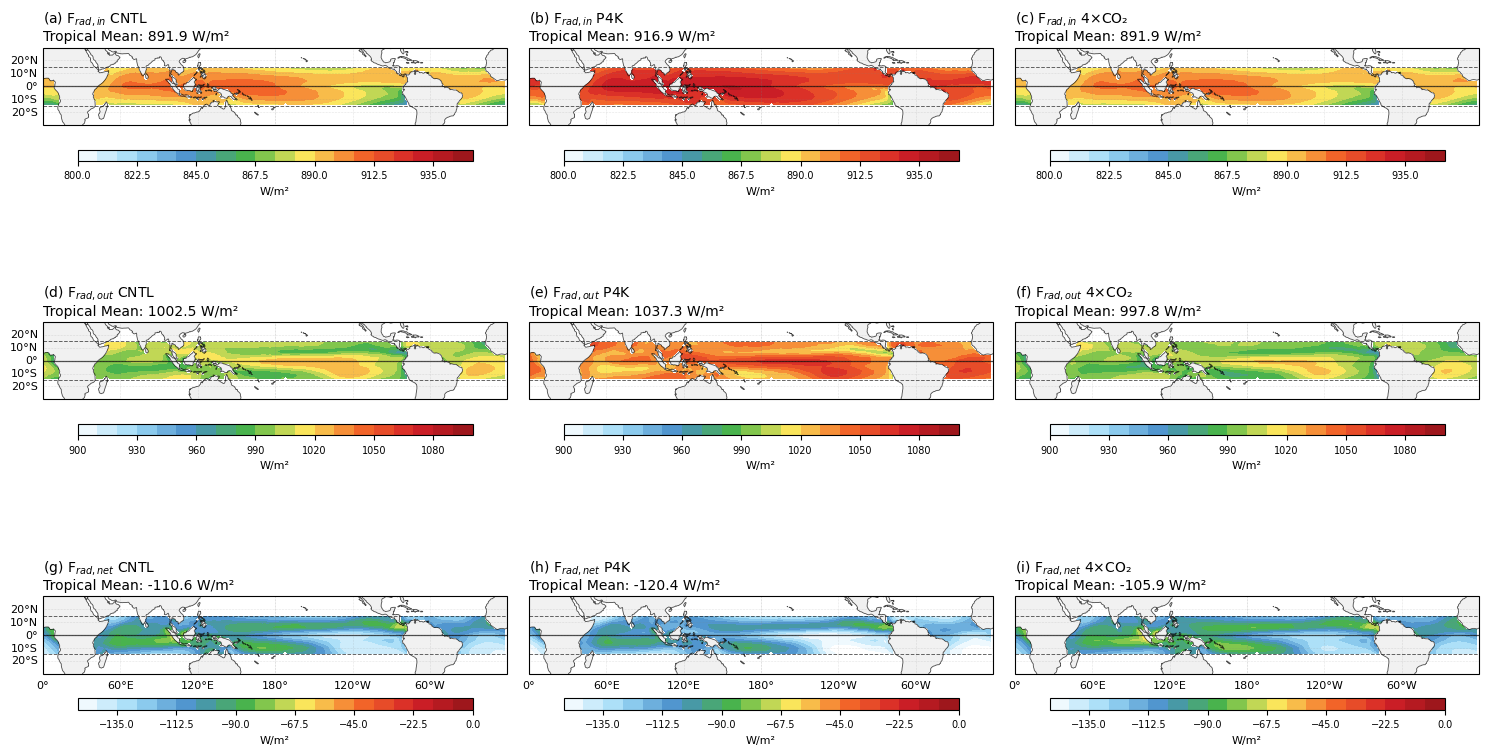

In [18]:
# 步骤10.3: 可视化纯辐射通量气候态空间分布（3x3布局）
print("="*70)
print("📊 可视化纯辐射通量气候态空间分布（3x3布局）")
print("="*70)

# 准备9个字段数据（3个实验 × 3个通量）
field_list_rad_clim = [
    F_rad_in_ocean["CNTL"], F_rad_in_ocean["P4K"], F_rad_in_ocean["4CO2"],
    F_rad_out_ocean["CNTL"], F_rad_out_ocean["P4K"], F_rad_out_ocean["4CO2"],
    F_rad_net_ocean["CNTL"], F_rad_net_ocean["P4K"], F_rad_net_ocean["4CO2"]
]

titles_rad_clim = [
    '(a) F$_{rad,in}$ CNTL', '(b) F$_{rad,in}$ P4K', '(c) F$_{rad,in}$ 4×CO₂',
    '(d) F$_{rad,out}$ CNTL', '(e) F$_{rad,out}$ P4K', '(f) F$_{rad,out}$ 4×CO₂',
    '(g) F$_{rad,net}$ CNTL', '(h) F$_{rad,net}$ P4K', '(i) F$_{rad,net}$ 4×CO₂'
]

# 颜色映射与范围设置
cmaps_rad_clim = [
    cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed,
    cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed, cmaps.WhiteBlueGreenYellowRed,
    cmaps.WhiteBlueGreenYellowRed,cmaps.WhiteBlueGreenYellowRed,cmaps.WhiteBlueGreenYellowRed,
]

vmins_rad_clim = [800, 800, 800,    # F_rad_in
                  900, 900, 900,    # F_rad_out
                  -150, -150, -150] # F_rad_net
vmaxs_rad_clim = [950, 950, 950, # F_rad_in
                  1100, 1100, 1100, # F_rad_out
                  0, 0, 0]    # F_rad_net

# 图像布局
fig, axes = plt.subplots(3, 3, figsize=(15, 9), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

# 限制绘图区域
lat_lim = (-30, 30)
lon_lim = (0, 360)

for i, (ax, data) in enumerate(zip(axes, field_list_rad_clim)):
    # 绘制填色图
    im = ax.contourf(
        data.lon, data.lat, data,
        levels=np.linspace(vmins_rad_clim[i], vmaxs_rad_clim[i], 21),
        cmap=cmaps_rad_clim[i],
        extend='neither',
        transform=ccrs.PlateCarree()
    )
    
    # 设置地图范围
    ax.set_extent([lon_lim[0], lon_lim[1], lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    
    # 地图设置
    ax.coastlines(linewidth=0.6, color='black', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
    
    # 添加关键纬度线
    ax.axhline(y=15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=-15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.9, alpha=0.7, zorder=2)
    
    # 网格线
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle=':', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    
    # 控制标签显示
    if i % 3 != 0:
        gl.left_labels = False
    if i < 6:
        gl.bottom_labels = False
    
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    
    # 计算热带平均值
    tropical_mean = float(tropical_mean_flux(data))
    
    # 标题
    ax.set_title(f'{titles_rad_clim[i]}\nTropical Mean: {tropical_mean:.1f} W/m²', 
                fontsize=10, loc='left', pad=5)
    
    # 添加colorbar
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', 
                     pad=0.08, aspect=35, shrink=0.85)
    cb.set_label('W/m²', fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'radiation_only_flux_climatology_3x3_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

📊 可视化纯辐射通量差异（3x2布局）
✅ 已保存: ./figures/Cal_radiation/radiation_only_flux_difference_3x2_ocean.png


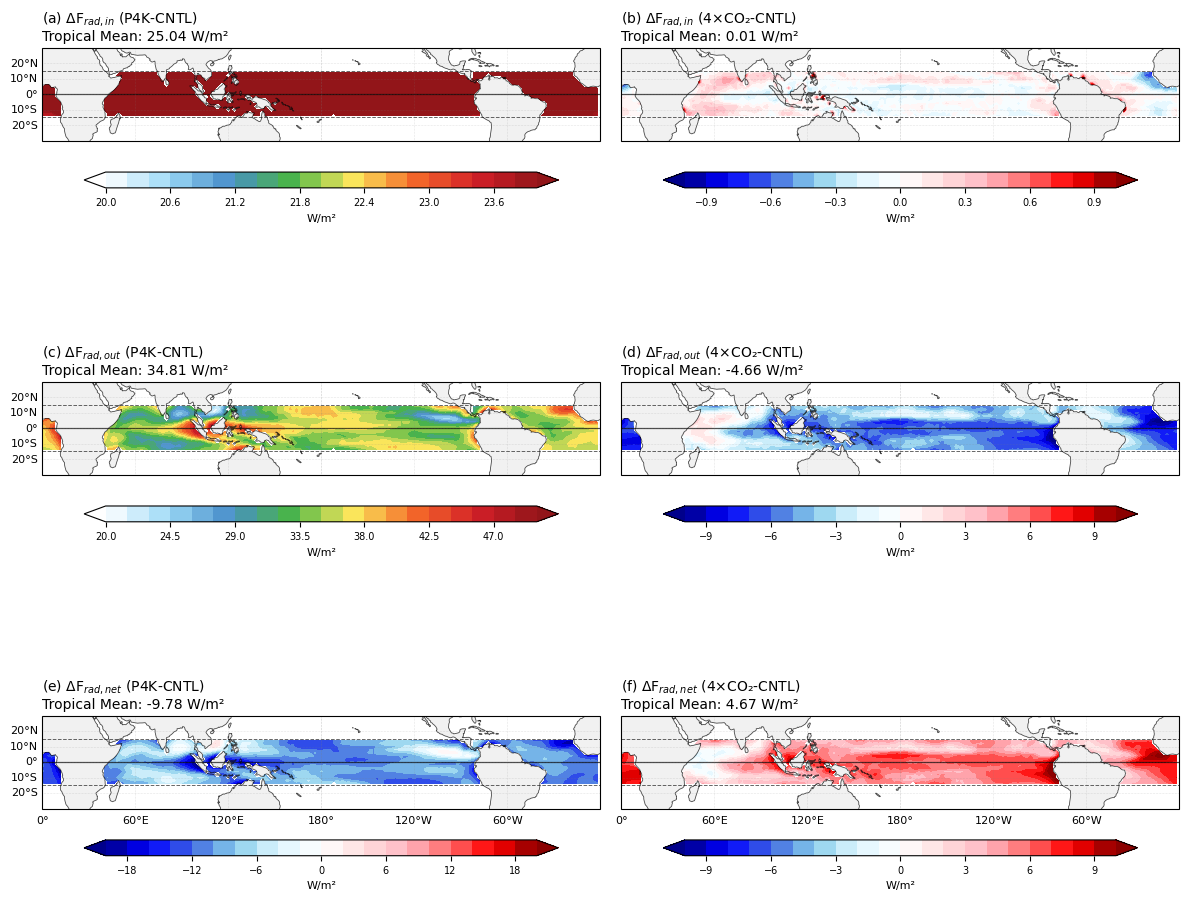

In [19]:
# 步骤10.4: 可视化纯辐射通量差异（3x2布局）
print("="*70)
print("📊 可视化纯辐射通量差异（3x2布局）")
print("="*70)

# 准备6个差异字段（2个实验对比 × 3个通量）
field_list_rad_diff = [
    F_rad_in_diff_ocean["P4K-CNTL"], F_rad_in_diff_ocean["4CO2-CNTL"],
    F_rad_out_diff_ocean["P4K-CNTL"], F_rad_out_diff_ocean["4CO2-CNTL"],
    F_rad_net_diff_ocean["P4K-CNTL"], F_rad_net_diff_ocean["4CO2-CNTL"]
]

titles_rad_diff = [
    '(a) ΔF$_{rad,in}$ (P4K-CNTL)', '(b) ΔF$_{rad,in}$ (4×CO₂-CNTL)',
    '(c) ΔF$_{rad,out}$ (P4K-CNTL)', '(d) ΔF$_{rad,out}$ (4×CO₂-CNTL)',
    '(e) ΔF$_{rad,net}$ (P4K-CNTL)', '(f) ΔF$_{rad,net}$ (4×CO₂-CNTL)'
]

# 统一使用发散型色标
cmaps_rad_diff = [cmaps.WhiteBlueGreenYellowRed, mycmap,
                  cmaps.WhiteBlueGreenYellowRed, mycmap,
                  mycmap, mycmap]

# 差异场统一范围
vmins_rad_diff = [20, -1,   # ΔF_rad_in
                  20, -10,   # ΔF_rad_out
                  -20, -10]   # ΔF_rad_net
vmaxs_rad_diff = [24, 1,     # ΔF_rad_in
                  50, 10,     # ΔF_rad_out
                  20, 10]     # ΔF_rad_net

# 图像布局
fig, axes = plt.subplots(3, 2, figsize=(12, 11), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

# 限制绘图区域
lat_lim = (-30, 30)
lon_lim = (0, 360)

for i, (ax, data) in enumerate(zip(axes, field_list_rad_diff)):
    # 绘制填色图
    im = ax.contourf(
        data.lon, data.lat, data,
        levels=np.linspace(vmins_rad_diff[i], vmaxs_rad_diff[i], 21),
        cmap=cmaps_rad_diff[i],
        extend='both',
        transform=ccrs.PlateCarree()
    )
    
    # 设置地图范围
    ax.set_extent([lon_lim[0], lon_lim[1], lat_lim[0], lat_lim[1]], crs=ccrs.PlateCarree())
    
    # 地图设置
    ax.coastlines(linewidth=0.6, color='black', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
    
    # 添加关键纬度线
    ax.axhline(y=15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=-15, color='black', linestyle='--', linewidth=0.7, alpha=0.6, zorder=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.9, alpha=0.7, zorder=2)
    
    # 网格线
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle=':', color='gray')
    gl.top_labels = False
    gl.right_labels = False
    
    # 控制标签显示
    if i % 2 != 0:
        gl.left_labels = False
    if i < 4:
        gl.bottom_labels = False
    
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    
    # 计算热带平均值
    tropical_mean = float(tropical_mean_flux(data))
    
    # 标题
    ax.set_title(f'{titles_rad_diff[i]}\nTropical Mean: {tropical_mean:.2f} W/m²', 
                fontsize=10, loc='left', pad=5)
    
    # 添加colorbar
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', 
                     pad=0.08, aspect=30, shrink=0.85)
    cb.set_label('W/m²', fontsize=8)
    cb.ax.tick_params(labelsize=7)

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'radiation_only_flux_difference_3x2_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

In [20]:
# 步骤10.5: 纯辐射通量各分量的定量分析
print("="*70)
print("📊 纯辐射通量各分量的定量分析")
print("="*70)

# 辐射通量入射分量
rad_in_components = ["rsdt", "rlus", "rsus"]
print("\n【纯辐射入射通量分量】")
print(f"{'Component':<12} {'CNTL':>10} {'P4K':>10} {'4×CO₂':>10} {'P4K-CNTL':>12} {'4×CO₂-CNTL':>14}")
print("-" * 70)

for comp in rad_in_components:
    cntl_val = float(tropical_mean_flux(rad_clim[comp]["CNTL"]))
    p4k_val = float(tropical_mean_flux(rad_clim[comp]["P4K"]))
    co2_val = float(tropical_mean_flux(rad_clim[comp]["4CO2"]))
    p4k_diff = float(tropical_mean_flux(rad_diff[comp]["P4K-CNTL"]))
    co2_diff = float(tropical_mean_flux(rad_diff[comp]["4CO2-CNTL"]))
    print(f"{comp:<12} {cntl_val:>10.2f} {p4k_val:>10.2f} {co2_val:>10.2f} {p4k_diff:>12.2f} {co2_diff:>14.2f}")

# 计算纯辐射入射总量
cntl_rad_in = float(tropical_mean_flux(F_rad_in_ocean["CNTL"]))
p4k_rad_in = float(tropical_mean_flux(F_rad_in_ocean["P4K"]))
co2_rad_in = float(tropical_mean_flux(F_rad_in_ocean["4CO2"]))
p4k_rad_in_diff = float(tropical_mean_flux(F_rad_in_diff_ocean["P4K-CNTL"]))
co2_rad_in_diff = float(tropical_mean_flux(F_rad_in_diff_ocean["4CO2-CNTL"]))

print("-" * 70)
print(f"{'F_rad_in':<12} {cntl_rad_in:>10.2f} {p4k_rad_in:>10.2f} {co2_rad_in:>10.2f} {p4k_rad_in_diff:>12.2f} {co2_rad_in_diff:>14.2f}")

# 辐射通量出射分量
rad_out_components = ["rsut", "rlut", "rsds", "rlds"]
print("\n【纯辐射出射通量分量】")
print(f"{'Component':<12} {'CNTL':>10} {'P4K':>10} {'4×CO₂':>10} {'P4K-CNTL':>12} {'4×CO₂-CNTL':>14}")
print("-" * 70)

for comp in rad_out_components:
    cntl_val = float(tropical_mean_flux(rad_clim[comp]["CNTL"]))
    p4k_val = float(tropical_mean_flux(rad_clim[comp]["P4K"]))
    co2_val = float(tropical_mean_flux(rad_clim[comp]["4CO2"]))
    p4k_diff = float(tropical_mean_flux(rad_diff[comp]["P4K-CNTL"]))
    co2_diff = float(tropical_mean_flux(rad_diff[comp]["4CO2-CNTL"]))
    print(f"{comp:<12} {cntl_val:>10.2f} {p4k_val:>10.2f} {co2_val:>10.2f} {p4k_diff:>12.2f} {co2_diff:>14.2f}")

# 计算纯辐射出射总量
cntl_rad_out = float(tropical_mean_flux(F_rad_out_ocean["CNTL"]))
p4k_rad_out = float(tropical_mean_flux(F_rad_out_ocean["P4K"]))
co2_rad_out = float(tropical_mean_flux(F_rad_out_ocean["4CO2"]))
p4k_rad_out_diff = float(tropical_mean_flux(F_rad_out_diff_ocean["P4K-CNTL"]))
co2_rad_out_diff = float(tropical_mean_flux(F_rad_out_diff_ocean["4CO2-CNTL"]))

print("-" * 70)
print(f"{'F_rad_out':<12} {cntl_rad_out:>10.2f} {p4k_rad_out:>10.2f} {co2_rad_out:>10.2f} {p4k_rad_out_diff:>12.2f} {co2_rad_out_diff:>14.2f}")

# 净辐射通量
print("\n【净辐射通量】")
print(f"{'Component':<12} {'CNTL':>10} {'P4K':>10} {'4×CO₂':>10} {'P4K-CNTL':>12} {'4×CO₂-CNTL':>14}")
print("-" * 70)

cntl_rad_net = float(tropical_mean_flux(F_rad_net_ocean["CNTL"]))
p4k_rad_net = float(tropical_mean_flux(F_rad_net_ocean["P4K"]))
co2_rad_net = float(tropical_mean_flux(F_rad_net_ocean["4CO2"]))
p4k_rad_net_diff = float(tropical_mean_flux(F_rad_net_diff_ocean["P4K-CNTL"]))
co2_rad_net_diff = float(tropical_mean_flux(F_rad_net_diff_ocean["4CO2-CNTL"]))

print(f"{'F_rad_net':<12} {cntl_rad_net:>10.2f} {p4k_rad_net:>10.2f} {co2_rad_net:>10.2f} {p4k_rad_net_diff:>12.2f} {co2_rad_net_diff:>14.2f}")

print("="*70)

📊 纯辐射通量各分量的定量分析

【纯辐射入射通量分量】
Component          CNTL        P4K      4×CO₂     P4K-CNTL     4×CO₂-CNTL
----------------------------------------------------------------------
rsdt             411.39     411.39     411.39         0.00           0.00
rlus             463.14     488.35     463.17        25.20           0.03
rsus              17.35      17.19      17.33        -0.17          -0.03
----------------------------------------------------------------------
F_rad_in         891.89     916.92     891.89        25.04           0.01

【纯辐射出射通量分量】
Component          CNTL        P4K      4×CO₂     P4K-CNTL     4×CO₂-CNTL
----------------------------------------------------------------------
rsut              89.26      85.51      88.09        -3.75          -1.17
rlut             260.83     267.34     253.09         6.51          -7.74
rsds             246.84     244.44     246.48        -2.41          -0.36
rlds             405.56     440.01     410.16        34.46           4.61
-----

📊 纯辐射通量分量柱状图对比


✅ 已保存: ./figures/Cal_radiation/radiation_only_components_bar_chart_ocean.png


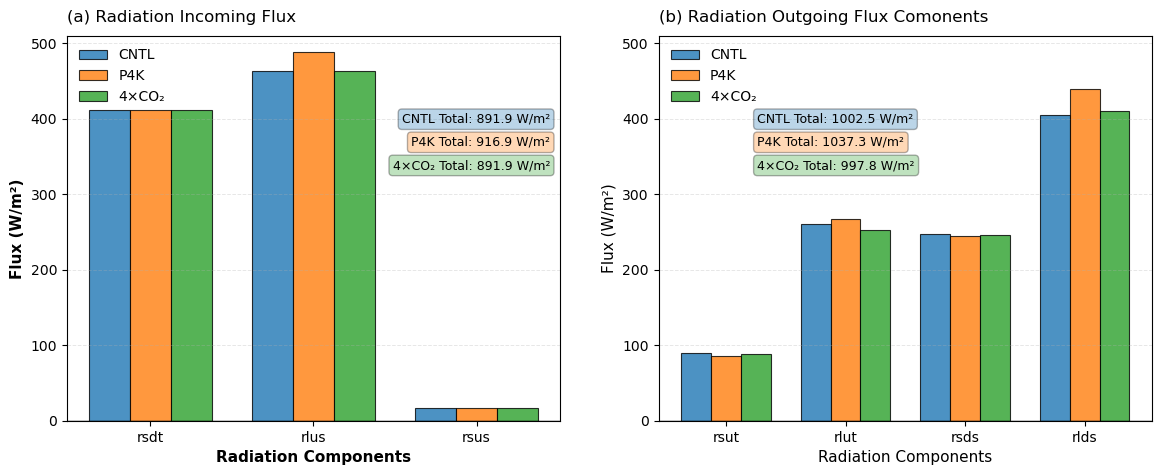

In [21]:
# 步骤10.6: 纯辐射通量分量柱状图对比
print("="*70)
print("📊 纯辐射通量分量柱状图对比")
print("="*70)

# 准备数据：入射分量
rad_in_data = {
    "CNTL": [
        float(tropical_mean_flux(rad_clim["rsdt"]["CNTL"])),
        float(tropical_mean_flux(rad_clim["rlus"]["CNTL"])),
        float(tropical_mean_flux(rad_clim["rsus"]["CNTL"]))
    ],
    "P4K": [
        float(tropical_mean_flux(rad_clim["rsdt"]["P4K"])),
        float(tropical_mean_flux(rad_clim["rlus"]["P4K"])),
        float(tropical_mean_flux(rad_clim["rsus"]["P4K"]))
    ],
    "4×CO₂": [
        float(tropical_mean_flux(rad_clim["rsdt"]["4CO2"])),
        float(tropical_mean_flux(rad_clim["rlus"]["4CO2"])),
        float(tropical_mean_flux(rad_clim["rsus"]["4CO2"]))
    ]
}

# 准备数据：出射分量
rad_out_data = {
    "CNTL": [
        float(tropical_mean_flux(rad_clim["rsut"]["CNTL"])),
        float(tropical_mean_flux(rad_clim["rlut"]["CNTL"])),
        float(tropical_mean_flux(rad_clim["rsds"]["CNTL"])),
        float(tropical_mean_flux(rad_clim["rlds"]["CNTL"]))
    ],
    "P4K": [
        float(tropical_mean_flux(rad_clim["rsut"]["P4K"])),
        float(tropical_mean_flux(rad_clim["rlut"]["P4K"])),
        float(tropical_mean_flux(rad_clim["rsds"]["P4K"])),
        float(tropical_mean_flux(rad_clim["rlds"]["P4K"]))
    ],
    "4×CO₂": [
        float(tropical_mean_flux(rad_clim["rsut"]["4CO2"])),
        float(tropical_mean_flux(rad_clim["rlut"]["4CO2"])),
        float(tropical_mean_flux(rad_clim["rsds"]["4CO2"])),
        float(tropical_mean_flux(rad_clim["rlds"]["4CO2"]))
    ]
}

# 创建图形：2行1列布局
fig, axes = plt.subplots(1,2, figsize=(14, 5))

# 第1行：入射分量 (F_rad_in)
ax1 = axes[0]
x_in = np.arange(len(rad_in_components))
width = 0.25
colors_exp = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (exp, color) in enumerate(zip(["CNTL", "P4K", "4×CO₂"], colors_exp)):
    ax1.bar(x_in + i * width, rad_in_data[exp], width, 
            label=exp, color=color, alpha=0.8, edgecolor='black', linewidth=0.8)

ax1.set_xlabel('Radiation Components', fontsize=11, fontweight='bold')
ax1.set_ylabel('Flux (W/m²)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Radiation Incoming Flux ', loc='left',
              fontsize=12,  pad=10)
ax1.set_xticks(x_in + width)
ax1.set_xticklabels(rad_in_components, fontsize=10)
ax1.legend(fontsize=10,  frameon=False,loc='upper left', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.0)

# 添加总和标注
for i, exp in enumerate(["CNTL", "P4K", "4×CO₂"]):
    total_in = sum(rad_in_data[exp])
    ax1.text(0.98, 0.80 - i*0.06, f'{exp} Total: {total_in:.1f} W/m²', 
            transform=ax1.transAxes, fontsize=9, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor=colors_exp[i], alpha=0.3))
ax1.set_ylim(0,510)
# 第2行：出射分量 (F_rad_out)
ax2 = axes[1]
x_out = np.arange(len(rad_out_components))

for i, (exp, color) in enumerate(zip(["CNTL", "P4K", "4×CO₂"], colors_exp)):
    ax2.bar(x_out + i * width, rad_out_data[exp], width, 
            label=exp, color=color, alpha=0.8, edgecolor='black', linewidth=0.8)

ax2.set_xlabel('Radiation Components', fontsize=11, )
ax2.set_ylabel('Flux (W/m²)', fontsize=11, )
ax2.set_title('(b) Radiation Outgoing Flux Comonents ', loc='left',
              fontsize=12, pad=10)
ax2.set_xticks(x_out + width)
ax2.set_xticklabels(rad_out_components, fontsize=10)
ax2.legend(fontsize=10,  frameon=False,loc='best', framealpha=0.9)
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.0)

# 添加总和标注
for i, exp in enumerate(["CNTL", "P4K", "4×CO₂"]):
    total_out = sum(rad_out_data[exp])
    ax2.text(0.2, 0.80 - i*0.06, f'{exp} Total: {total_out:.1f} W/m²', 
            transform=ax2.transAxes, fontsize=9, 
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor=colors_exp[i], alpha=0.3))
ax2.set_ylim(0,510)
# plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'radiation_only_components_bar_chart_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

📊 纯辐射通量差异柱状图对比
✅ 已保存: ./figures/Cal_radiation/radiation_only_differences_bar_chart_ocean.png


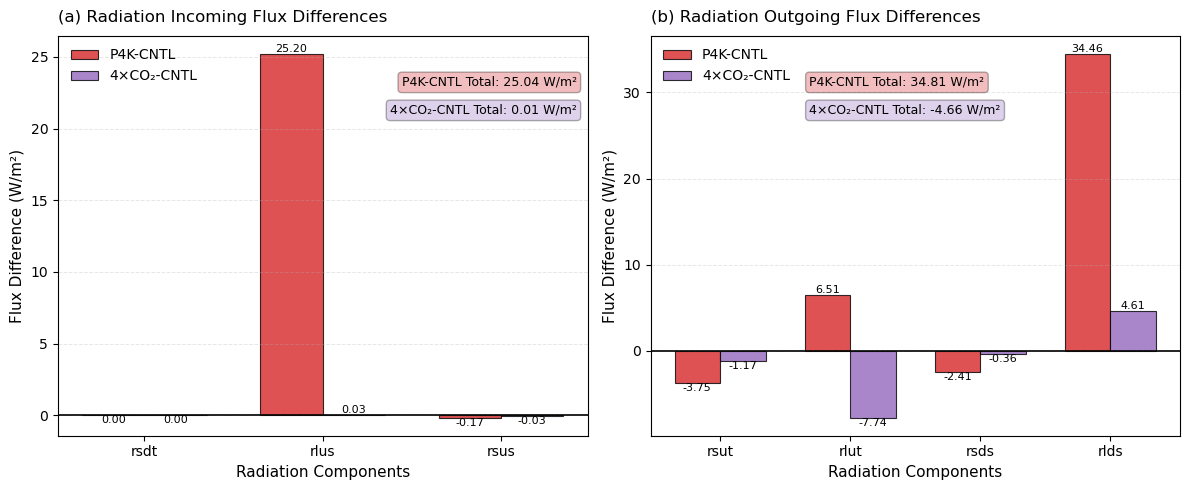

In [22]:
# 步骤10.7: 纯辐射通量差异柱状图对比
print("="*70)
print("📊 纯辐射通量差异柱状图对比")
print("="*70)

# 准备差异数据：入射分量
rad_in_diff_data = {
    "P4K-CNTL": [
        float(tropical_mean_flux(rad_diff["rsdt"]["P4K-CNTL"])),
        float(tropical_mean_flux(rad_diff["rlus"]["P4K-CNTL"])),
        float(tropical_mean_flux(rad_diff["rsus"]["P4K-CNTL"]))
    ],
    "4×CO₂-CNTL": [
        float(tropical_mean_flux(rad_diff["rsdt"]["4CO2-CNTL"])),
        float(tropical_mean_flux(rad_diff["rlus"]["4CO2-CNTL"])),
        float(tropical_mean_flux(rad_diff["rsus"]["4CO2-CNTL"]))
    ]
}

# 准备差异数据：出射分量
rad_out_diff_data = {
    "P4K-CNTL": [
        float(tropical_mean_flux(rad_diff["rsut"]["P4K-CNTL"])),
        float(tropical_mean_flux(rad_diff["rlut"]["P4K-CNTL"])),
        float(tropical_mean_flux(rad_diff["rsds"]["P4K-CNTL"])),
        float(tropical_mean_flux(rad_diff["rlds"]["P4K-CNTL"]))
    ],
    "4×CO₂-CNTL": [
        float(tropical_mean_flux(rad_diff["rsut"]["4CO2-CNTL"])),
        float(tropical_mean_flux(rad_diff["rlut"]["4CO2-CNTL"])),
        float(tropical_mean_flux(rad_diff["rsds"]["4CO2-CNTL"])),
        float(tropical_mean_flux(rad_diff["rlds"]["4CO2-CNTL"]))
    ]
}

# 创建图形：2行1列布局
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 第1行：入射分量差异 (ΔF_rad_in)
ax1 = axes[0]
x_in = np.arange(len(rad_in_components))
width = 0.35
colors_diff = ['#d62728', '#9467bd']

for i, (exp_diff, color) in enumerate(zip(["P4K-CNTL", "4×CO₂-CNTL"], colors_diff)):
    values = rad_in_diff_data[exp_diff]
    bars = ax1.bar(x_in + i * width, values, width, 
                   label=exp_diff, color=color, alpha=0.8, edgecolor='black', linewidth=0.8)
    
    # 添加数值标注
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2., height,
                f'{val:.2f}', ha='center', va='bottom' if height > 0 else 'top', 
                fontsize=8, )

ax1.set_xlabel('Radiation Components', fontsize=11, )
ax1.set_ylabel('Flux Difference (W/m²)', fontsize=11, )
ax1.set_title('(a) Radiation Incoming Flux Differences', loc='left',
              fontsize=12,  pad=10)
ax1.set_xticks(x_in + width / 2)
ax1.set_xticklabels(rad_in_components, fontsize=10)
ax1.legend(fontsize=10, frameon=False,loc='upper left', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.2)

# 添加总和标注
for i, exp_diff in enumerate(["P4K-CNTL", "4×CO₂-CNTL"]):
    total_diff = sum(rad_in_diff_data[exp_diff])
    ax1.text(0.98, 0.90 - i*0.07, f'{exp_diff} Total: {total_diff:.2f} W/m²', 
            transform=ax1.transAxes, fontsize=9, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor=colors_diff[i], alpha=0.3))

# 第2行：出射分量差异 (ΔF_rad_out)
ax2 = axes[1]
x_out = np.arange(len(rad_out_components))

for i, (exp_diff, color) in enumerate(zip(["P4K-CNTL", "4×CO₂-CNTL"], colors_diff)):
    values = rad_out_diff_data[exp_diff]
    bars = ax2.bar(x_out + i * width, values, width, 
                   label=exp_diff, color=color, alpha=0.8, edgecolor='black', linewidth=0.8)
    
    # 添加数值标注
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2., height,
                f'{val:.2f}', ha='center', va='bottom' if height > 0 else 'top', 
                fontsize=8, )

ax2.set_xlabel('Radiation Components', fontsize=11, )
ax2.set_ylabel('Flux Difference (W/m²)', fontsize=11, )
ax2.set_title('(b) Radiation Outgoing Flux Differences', loc='left',
              fontsize=12,  pad=10)
ax2.set_xticks(x_out + width / 2)
ax2.set_xticklabels(rad_out_components, fontsize=10)
ax2.legend(fontsize=10, frameon=False,loc='best', framealpha=0.9)
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.2)

# 添加总和标注
for i, exp_diff in enumerate(["P4K-CNTL", "4×CO₂-CNTL"]):
    total_diff = sum(rad_out_diff_data[exp_diff])
    ax2.text(0.3, 0.90 - i*0.07, f'{exp_diff} Total: {total_diff:.2f} W/m²', 
            transform=ax2.transAxes, fontsize=9, 
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor=colors_diff[i], alpha=0.3))

plt.tight_layout()
save_path = os.path.join(fig_save_dir, 'radiation_only_differences_bar_chart_ocean.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

## 步骤11: 大气辐射冷却与湍流通量反馈分析

### 物理框架

**大气辐射冷却率 (Atmospheric Radiative Cooling):**

$$R_{atm} = F_{rad,in} - F_{rad,out} = (rsdt + rlus + rsus) - (rsut + rlut + rsds + rlds)$$

**湍流热通量 (Turbulent Heat Fluxes):**
- **潜热通量 (Latent Heat):** $LH = hfls$ (蒸发)
- **感热通量 (Sensible Heat):** $SH = hfss$ (对流)

### 分析目标

比较不同实验间的变化：
- $\Delta R_{atm} = R_{atm,exp} - R_{atm,cntl}$
- $\Delta LH = LH_{exp} - LH_{cntl}$
- $\Delta SH = SH_{exp} - SH_{cntl}$

### 物理解释

1. **若 $\Delta R_{atm}$ 减弱（冷却减弱）且 $\Delta LH$、$\Delta SH$ 同向减小**
   - 说明：**对流反馈削弱**
   - 机制：辐射冷却减弱 → 对流活动减弱 → 湍流输送减少

2. **若 $\Delta R_{atm}$ 减弱但 $\Delta LH$ 增强**
   - 说明：**蒸发加剧补偿辐射冷却**
   - 机制：表面增暖 → 蒸发增强 → 潜热释放补偿辐射能量损失

In [23]:
# 步骤11.1: 计算大气辐射冷却率 R_atm
print("="*70)
print("🧮 计算大气辐射冷却率 R_atm")
print("="*70)

# R_atm = F_rad_net (已经在步骤10.1中计算)
# R_atm = F_rad_in - F_rad_out = (rsdt + rlus + rsus) - (rsut + rlut + rsds + rlds)
R_atm = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    R_atm[exp] = F_rad_net[exp]
    print(f"✅ R_atm [{exp}]: 大气辐射冷却率计算完成")

# 应用海洋mask
R_atm_ocean = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    R_atm_ocean[exp] = R_atm[exp].where(ocean_mask_2deg_binary == 1)

# 计算差异
R_atm_diff_ocean = {
    "P4K-CNTL": R_atm_ocean["P4K"] - R_atm_ocean["CNTL"],
    "4CO2-CNTL": R_atm_ocean["4CO2"] - R_atm_ocean["CNTL"]
}

# 计算热带平均值
print("\n" + "="*70)
print("📊 大气辐射冷却率热带平均 (W/m², 15°S-15°N Ocean)")
print("="*70)
print(f"{'Experiment':<15} {'R_atm (W/m²)':>15}")
print("-" * 70)

for exp in ["CNTL", "P4K", "4CO2"]:
    r_atm_mean = float(tropical_mean_flux(R_atm_ocean[exp]))
    print(f"{exp:<15} {r_atm_mean:>15.2f}")

print("\n" + "="*70)
print("📊 大气辐射冷却率变化 ΔR_atm (W/m²)")
print("="*70)
print(f"{'Difference':<15} {'ΔR_atm (W/m²)':>15}")
print("-" * 70)

delta_R_atm = {}
for exp_diff in ["P4K-CNTL", "4CO2-CNTL"]:
    delta_r_atm = float(tropical_mean_flux(R_atm_diff_ocean[exp_diff]))
    delta_R_atm[exp_diff] = delta_r_atm
    print(f"{exp_diff:<15} {delta_r_atm:>15.2f}")

print("\n💡 物理意义:")
print("   - R_atm > 0: 大气净辐射加热")
print("   - R_atm < 0: 大气净辐射冷却")
print("   - ΔR_atm > 0: 辐射冷却减弱（或加热增强）")
print("   - ΔR_atm < 0: 辐射冷却增强（或加热减弱）")
print("="*70)

🧮 计算大气辐射冷却率 R_atm
✅ R_atm [CNTL]: 大气辐射冷却率计算完成
✅ R_atm [P4K]: 大气辐射冷却率计算完成
✅ R_atm [4CO2]: 大气辐射冷却率计算完成

📊 大气辐射冷却率热带平均 (W/m², 15°S-15°N Ocean)
Experiment         R_atm (W/m²)
----------------------------------------------------------------------
CNTL                    -110.60
P4K                     -120.38
4CO2                    -105.94

📊 大气辐射冷却率变化 ΔR_atm (W/m²)
Difference        ΔR_atm (W/m²)
----------------------------------------------------------------------
P4K-CNTL                  -9.78
4CO2-CNTL                  4.67

💡 物理意义:
   - R_atm > 0: 大气净辐射加热
   - R_atm < 0: 大气净辐射冷却
   - ΔR_atm > 0: 辐射冷却减弱（或加热增强）
   - ΔR_atm < 0: 辐射冷却增强（或加热减弱）


In [24]:
# 步骤11.2: 提取湍流热通量（潜热和感热）
print("="*70)
print("🧮 分析湍流热通量变化")
print("="*70)

# 潜热通量 (Latent Heat) - hfls
LH = {}
LH_ocean = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    LH[exp] = rad_clim["hfls"][exp]
    LH_ocean[exp] = LH[exp].where(ocean_mask_2deg_binary == 1)

LH_diff_ocean = {
    "P4K-CNTL": LH_ocean["P4K"] - LH_ocean["CNTL"],
    "4CO2-CNTL": LH_ocean["4CO2"] - LH_ocean["CNTL"]
}

# 感热通量 (Sensible Heat) - hfss
SH = {}
SH_ocean = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    SH[exp] = rad_clim["hfss"][exp]
    SH_ocean[exp] = SH[exp].where(ocean_mask_2deg_binary == 1)

SH_diff_ocean = {
    "P4K-CNTL": SH_ocean["P4K"] - SH_ocean["CNTL"],
    "4CO2-CNTL": SH_ocean["4CO2"] - SH_ocean["CNTL"]
}

# 打印统计信息
print("\n" + "="*70)
print("📊 湍流热通量热带平均 (W/m², 15°S-15°N Ocean)")
print("="*70)
print(f"{'Experiment':<15} {'LH (潜热)':>15} {'SH (感热)':>15} {'LH+SH (总)':>15}")
print("-" * 70)

for exp in ["CNTL", "P4K", "4CO2"]:
    lh_mean = float(tropical_mean_flux(LH_ocean[exp]))
    sh_mean = float(tropical_mean_flux(SH_ocean[exp]))
    total_turb = lh_mean + sh_mean
    print(f"{exp:<15} {lh_mean:>15.2f} {sh_mean:>15.2f} {total_turb:>15.2f}")

print("\n" + "="*70)
print("📊 湍流热通量变化 (W/m²)")
print("="*70)
print(f"{'Difference':<15} {'ΔLH':>15} {'ΔSH':>15} {'Δ(LH+SH)':>15}")
print("-" * 70)

delta_LH = {}
delta_SH = {}
delta_turb = {}

for exp_diff in ["P4K-CNTL", "4CO2-CNTL"]:
    dlh = float(tropical_mean_flux(LH_diff_ocean[exp_diff]))
    dsh = float(tropical_mean_flux(SH_diff_ocean[exp_diff]))
    delta_LH[exp_diff] = dlh
    delta_SH[exp_diff] = dsh
    delta_turb[exp_diff] = dlh + dsh
    print(f"{exp_diff:<15} {dlh:>15.2f} {dsh:>15.2f} {delta_turb[exp_diff]:>15.2f}")

print("="*70)

🧮 分析湍流热通量变化

📊 湍流热通量热带平均 (W/m², 15°S-15°N Ocean)
Experiment              LH (潜热)         SH (感热)       LH+SH (总)
----------------------------------------------------------------------
CNTL                     131.49           11.85          143.34
P4K                      148.32           10.40          158.72
4CO2                     124.57           10.63          135.20

📊 湍流热通量变化 (W/m²)
Difference                  ΔLH             ΔSH        Δ(LH+SH)
----------------------------------------------------------------------
P4K-CNTL                  16.83           -1.45           15.38
4CO2-CNTL                 -6.92           -1.22           -8.14


In [25]:
# 步骤11.3: 综合分析 - 辐射冷却与湍流反馈
print("="*70)
print("🔬 大气辐射冷却与湍流热通量反馈综合分析")
print("="*70)

# 创建对比表格
print("\n" + "="*70)
print("📊 完整对比分析表")
print("="*70)
print(f"{'实验对比':<15} {'ΔR_atm':>12} {'ΔLH':>12} {'ΔSH':>12} {'Δ(LH+SH)':>12}")
print("-" * 70)

for exp_diff in ["P4K-CNTL", "4CO2-CNTL"]:
    print(f"{exp_diff:<15} {delta_R_atm[exp_diff]:>12.2f} {delta_LH[exp_diff]:>12.2f} "
          f"{delta_SH[exp_diff]:>12.2f} {delta_turb[exp_diff]:>12.2f}")

# 物理机制诊断
print("\n" + "="*70)
print("🔍 物理机制诊断")
print("="*70)

for exp_diff in ["P4K-CNTL", "4CO2-CNTL"]:
    print(f"\n【{exp_diff}】")
    print("-" * 70)
    
    dr_atm = delta_R_atm[exp_diff]
    dlh = delta_LH[exp_diff]
    dsh = delta_SH[exp_diff]
    dturb = delta_turb[exp_diff]
    
    # 判断辐射冷却变化
    if dr_atm > 0:
        rad_status = "减弱"
        rad_change = "辐射冷却减弱（净辐射加热增强）"
    elif dr_atm < 0:
        rad_status = "增强"
        rad_change = "辐射冷却增强（净辐射加热减弱）"
    else:
        rad_status = "不变"
        rad_change = "辐射冷却无显著变化"
    
    print(f"1️⃣  辐射冷却变化: ΔR_atm = {dr_atm:.2f} W/m² → {rad_change}")
    
    # 判断湍流通量变化
    if dlh > 0 and dsh > 0:
        turb_status = "潜热和感热均增强"
    elif dlh < 0 and dsh < 0:
        turb_status = "潜热和感热均减弱"
    elif dlh > 0 and dsh < 0:
        turb_status = "潜热增强，感热减弱"
    elif dlh < 0 and dsh > 0:
        turb_status = "潜热减弱，感热增强"
    else:
        turb_status = "湍流通量无显著变化"
    
    print(f"2️⃣  湍流通量变化: ΔLH = {dlh:.2f} W/m², ΔSH = {dsh:.2f} W/m²")
    print(f"    → {turb_status}")
    print(f"    → 总湍流通量变化: Δ(LH+SH) = {dturb:.2f} W/m²")
    
    # 物理机制判断
    print(f"\n3️⃣  物理机制判断:")
    
    # 情形1: 辐射冷却减弱 + 湍流通量同向减弱
    if dr_atm > 0 and dturb < 0:
        print(f"    ✅ 【对流反馈削弱】")
        print(f"       - 辐射冷却减弱 ({dr_atm:.2f} W/m²) → 大气层结趋于稳定")
        print(f"       - 对流活动减弱 → 湍流输送减少 ({dturb:.2f} W/m²)")
        print(f"       - 负反馈机制：稳定层结抑制对流发展")
    
    # 情形2: 辐射冷却减弱 + 潜热增强
    elif dr_atm > 0 and dlh > 0:
        print(f"    ✅ 【蒸发加剧补偿辐射冷却】")
        print(f"       - 辐射冷却减弱 ({dr_atm:.2f} W/m²) → 大气能量损失减少")
        print(f"       - 表面增暖 → 蒸发增强 ({dlh:.2f} W/m²)")
        print(f"       - 潜热释放补偿辐射能量损失")
        if dsh > 0:
            print(f"       - 感热也增强 ({dsh:.2f} W/m²)，进一步补偿")
        else:
            print(f"       - 但感热减弱 ({dsh:.2f} W/m²)，部分抵消")
    
    # 情形3: 辐射冷却增强 + 湍流通量增强
    elif dr_atm < 0 and dturb > 0:
        print(f"    ✅ 【对流活动增强】")
        print(f"       - 辐射冷却增强 ({dr_atm:.2f} W/m²) → 大气能量损失增加")
        print(f"       - 湍流通量增强 ({dturb:.2f} W/m²) → 对流输送加强")
        print(f"       - 正反馈：辐射冷却 → 不稳定层结 → 对流增强")
    
    # 情形4: 辐射冷却增强 + 湍流通量减弱
    elif dr_atm < 0 and dturb < 0:
        print(f"    ⚠️  【复杂反馈机制】")
        print(f"       - 辐射冷却增强 ({dr_atm:.2f} W/m²)")
        print(f"       - 但湍流通量减弱 ({dturb:.2f} W/m²)")
        print(f"       - 可能机制：表面冷却 → 蒸发减弱 → 对流受限")
    
    # 其他情况
    else:
        print(f"    ℹ️  【反馈机制不明显】")
        print(f"       - ΔR_atm = {dr_atm:.2f} W/m²")
        print(f"       - Δ(LH+SH) = {dturb:.2f} W/m²")
        print(f"       - 需要进一步分析其他因素")
    
    # 潜热vs感热的相对贡献
    if abs(dlh) > 0.1 or abs(dsh) > 0.1:
        lh_contribution = (dlh / dturb * 100) if dturb != 0 else 0
        sh_contribution = (dsh / dturb * 100) if dturb != 0 else 0
        print(f"\n4️⃣  湍流通量变化分解:")
        print(f"       - 潜热贡献: {lh_contribution:.1f}% ({dlh:.2f} W/m²)")
        print(f"       - 感热贡献: {sh_contribution:.1f}% ({dsh:.2f} W/m²)")
        
        if abs(dlh) > abs(dsh):
            print(f"       → 💧 潜热主导湍流变化（蒸发/降水过程）")
        else:
            print(f"       → 🌡️  感热主导湍流变化（直接热交换）")

print("\n" + "="*70)
print("✅ 综合分析完成")
print("="*70)

🔬 大气辐射冷却与湍流热通量反馈综合分析

📊 完整对比分析表
实验对比                  ΔR_atm          ΔLH          ΔSH     Δ(LH+SH)
----------------------------------------------------------------------
P4K-CNTL               -9.78        16.83        -1.45        15.38
4CO2-CNTL               4.67        -6.92        -1.22        -8.14

🔍 物理机制诊断

【P4K-CNTL】
----------------------------------------------------------------------
1️⃣  辐射冷却变化: ΔR_atm = -9.78 W/m² → 辐射冷却增强（净辐射加热减弱）
2️⃣  湍流通量变化: ΔLH = 16.83 W/m², ΔSH = -1.45 W/m²
    → 潜热增强，感热减弱
    → 总湍流通量变化: Δ(LH+SH) = 15.38 W/m²

3️⃣  物理机制判断:
    ✅ 【对流活动增强】
       - 辐射冷却增强 (-9.78 W/m²) → 大气能量损失增加
       - 湍流通量增强 (15.38 W/m²) → 对流输送加强
       - 正反馈：辐射冷却 → 不稳定层结 → 对流增强

4️⃣  湍流通量变化分解:
       - 潜热贡献: 109.4% (16.83 W/m²)
       - 感热贡献: -9.4% (-1.45 W/m²)
       → 💧 潜热主导湍流变化（蒸发/降水过程）

【4CO2-CNTL】
----------------------------------------------------------------------
1️⃣  辐射冷却变化: ΔR_atm = 4.67 W/m² → 辐射冷却减弱（净辐射加热增强）
2️⃣  湍流通量变化: ΔLH = -6.92 W/m², ΔSH = -1.22 W/m²
    → 潜热和感热均

📊 可视化：辐射冷却与湍流反馈对比
✅ 已保存: ./figures/Cal_radiation/radiative_cooling_turbulent_feedback_analysis.png


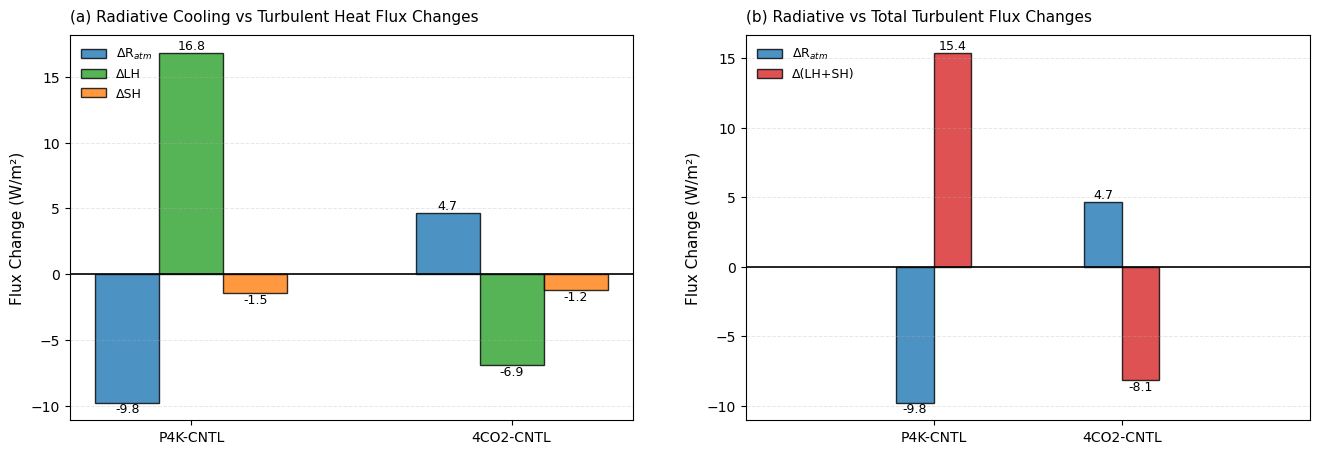

In [26]:
# 步骤11.4: 可视化 - 辐射冷却与湍流反馈对比
print("="*70)
print("📊 可视化：辐射冷却与湍流反馈对比")
print("="*70)

# 创建图形：2x2子图布局
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# 准备数据
experiments_list = ["P4K-CNTL", "4CO2-CNTL"]
x_pos = np.arange(len(experiments_list))
width = 0.2

# 颜色设置
color_Ratm = '#1f77b4'  # 蓝色 - 辐射
color_LH = '#2ca02c'    # 绿色 - 潜热
color_SH = '#ff7f0e'    # 橙色 - 感热
color_turb = '#d62728'  # 红色 - 总湍流

# ============================================================================
# 子图1: ΔR_atm, ΔLH, ΔSH 分项对比
# ============================================================================
ax1 = axes[0]
r_atm_vals = [delta_R_atm[exp] for exp in experiments_list]
lh_vals = [delta_LH[exp] for exp in experiments_list]
sh_vals = [delta_SH[exp] for exp in experiments_list]

bars1 = ax1.bar(x_pos - width, r_atm_vals, width, label='ΔR$_{atm}$', 
               color=color_Ratm, alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax1.bar(x_pos, lh_vals, width, label='ΔLH', 
               color=color_LH, alpha=0.8, edgecolor='black', linewidth=1)
bars3 = ax1.bar(x_pos + width, sh_vals, width, label='ΔSH', 
               color=color_SH, alpha=0.8, edgecolor='black', linewidth=1)

# 添加数值标注
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', 
                va='bottom' if height > 0 else 'top',
                fontsize=9, )

ax1.set_ylabel('Flux Change (W/m²)', fontsize=11, )
ax1.set_title('(a) Radiative Cooling vs Turbulent Heat Flux Changes', loc='left',
             fontsize=11,  pad=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(experiments_list, fontsize=10)
ax1.legend(fontsize=9,frameon=False, loc='upper left', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.2)

# ============================================================================
# 子图2: ΔR_atm vs Δ(LH+SH) 直接对比
# ============================================================================
ax2 = axes[1]
turb_vals = [delta_turb[exp] for exp in experiments_list]

bars4 = ax2.bar(x_pos - width/2, r_atm_vals, width*1., label='ΔR$_{atm}$', 
               color=color_Ratm, alpha=0.8, edgecolor='black', linewidth=1)
bars5 = ax2.bar(x_pos + width/2, turb_vals, width*1., label='Δ(LH+SH)', 
               color=color_turb, alpha=0.8, edgecolor='black', linewidth=1)

# 添加数值标注
for bars in [bars4, bars5]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', 
                va='bottom' if height > 0 else 'top',
                fontsize=9, )

ax2.set_ylabel('Flux Change (W/m²)', fontsize=11, )
ax2.set_title('(b) Radiative vs Total Turbulent Flux Changes', loc='left',
             fontsize=11,  pad=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(experiments_list, fontsize=10)
ax2.legend(fontsize=9, frameon=False,loc='upper left', framealpha=0.9)
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.2)
ax2.set_xlim(-1,2)
# ============================================================================
# 子图3: 散点图 - ΔR_atm vs Δ(LH+SH)
# ============================================================================
# ============================================================================
# 子图3: 散点图 - ΔR_atm vs Δ(LH+SH)
# ============================================================================


save_path = os.path.join(fig_save_dir, 'radiative_cooling_turbulent_feedback_analysis.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

print("="*70)

✅ 已保存: ./figures/Cal_radiation/feedback_analysis.png


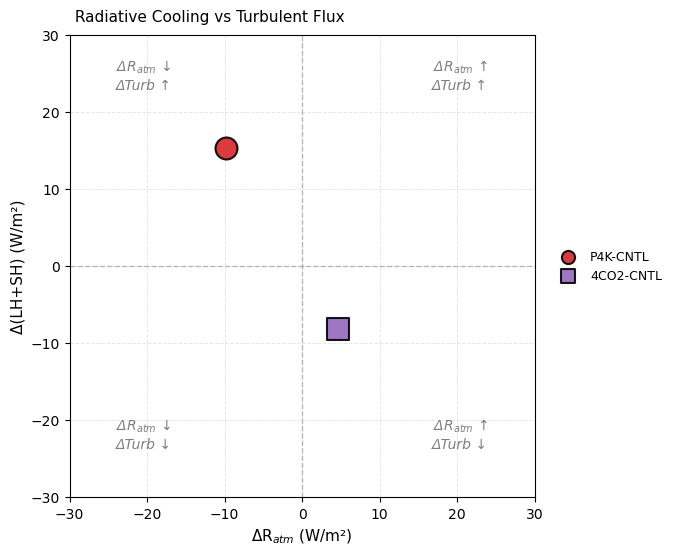

In [27]:
fig, ax4 = plt.subplots(1, 1, figsize=(6, 6))

# 绘制散点
colors_scatter = ['#d62728', '#9467bd']
markers = ['o', 's']
for i, (exp, color, marker) in enumerate(zip(experiments_list, colors_scatter, markers)):
    ax4.scatter(delta_R_atm[exp], delta_turb[exp], 
               s=250, c=color, marker=marker, alpha=0.9, 
               edgecolors='black', linewidth=1.5, label=exp, zorder=3)

# 添加参考线
ax4.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax4.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# ==================== 🧭 改进的象限标注 ====================
quad_text_style = dict(fontsize=10, alpha=0.5, style='italic')

# 稍微往内缩一点以防重叠
ax4.text(0.9, 0.95, 'ΔR$_{atm}$ ↑\nΔTurb ↑', 
         transform=ax4.transAxes, ha='right', va='top', **quad_text_style)
ax4.text(0.1, 0.95, 'ΔR$_{atm}$ ↓\nΔTurb ↑', 
         transform=ax4.transAxes, ha='left', va='top', **quad_text_style)
ax4.text(0.1, 0.1, 'ΔR$_{atm}$ ↓\nΔTurb ↓', 
         transform=ax4.transAxes, ha='left', va='bottom', **quad_text_style)
ax4.text(0.9, 0.1, 'ΔR$_{atm}$ ↑\nΔTurb ↓', 
         transform=ax4.transAxes, ha='right', va='bottom', **quad_text_style)

# ==================== 图形修饰 ====================
ax4.set_xlabel('ΔR$_{atm}$ (W/m²)', fontsize=11)
ax4.set_ylabel('Δ(LH+SH) (W/m²)', fontsize=11)
ax4.set_title(' Radiative Cooling vs Turbulent Flux', loc='left', fontsize=11, pad=10)

# Legend 放在右侧图外
ax4.legend(fontsize=9, frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5),
            markerscale=0.6  )

ax4.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax4.set_xlim(-30, 30)
ax4.set_ylim(-30, 30)


save_path = os.path.join(fig_save_dir, 'feedback_analysis.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()


## 步骤12: 净短波和净长波辐射分析

### 物理框架

为了更好地理解大气增温/冷却的物理过程，我们将辐射分解为：

1. **净短波辐射 (Net Shortwave at TOA)**:
   $$SW_{net,TOA} = rsdt - rsut$$
   - rsdt: 大气顶入射太阳辐射（向下）
   - rsut: 大气顶反射太阳辐射（向上）
   - 净效应：正值表示短波加热

2. **净长波辐射 (Net Longwave at TOA)**:
   $$LW_{net,TOA} = -rlut$$
   - rlut: 大气顶外逸长波辐射（向上）
   - 净效应：负值表示长波冷却（能量损失）

3. **TOA净辐射平衡**:
   $$R_{TOA} = SW_{net,TOA} + LW_{net,TOA} = (rsdt - rsut) - rlut$$

### 分析目标

比较不同实验间的变化，识别增温/冷却的主导过程：
- $\Delta SW_{net,TOA}$: 净短波辐射变化
- $\Delta LW_{net,TOA}$: 净长波辐射变化
- $\Delta R_{TOA}$: TOA净辐射不平衡

### 物理解释

- **若 $\Delta SW_{net,TOA} > 0$**: 短波加热增强（云反射减少或吸收增加）
- **若 $\Delta LW_{net,TOA} < 0$**: 长波冷却增强（OLR增加）
- **若 $\Delta R_{TOA} > 0$**: 净辐射不平衡，系统获得能量（增温）

In [28]:
# 步骤12.1: 计算TOA净短波和净长波辐射
print("="*70)
print("🌞 计算TOA净短波辐射 (SW_net,TOA = rsdt - rsut)")
print("="*70)

# 净短波辐射：rsdt - rsut（正值表示加热）
SW_net_TOA = {}
SW_net_TOA_ocean = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    SW_net_TOA[exp] = rad_clim["rsdt"][exp] - rad_clim["rsut"][exp]
    SW_net_TOA_ocean[exp] = SW_net_TOA[exp].where(ocean_mask_2deg_binary == 1)
    print(f"✅ SW_net_TOA [{exp}]: 净短波辐射计算完成")

# 计算差异
SW_net_TOA_diff_ocean = {
    "P4K-CNTL": SW_net_TOA_ocean["P4K"] - SW_net_TOA_ocean["CNTL"],
    "4CO2-CNTL": SW_net_TOA_ocean["4CO2"] - SW_net_TOA_ocean["CNTL"]
}

print("\n" + "="*70)
print("🌙 计算TOA净长波辐射 (LW_net,TOA = -rlut)")
print("="*70)

# 净长波辐射：-rlut（负值表示冷却）
LW_net_TOA = {}
LW_net_TOA_ocean = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    LW_net_TOA[exp] = -rad_clim["rlut"][exp]
    LW_net_TOA_ocean[exp] = LW_net_TOA[exp].where(ocean_mask_2deg_binary == 1)
    print(f"✅ LW_net_TOA [{exp}]: 净长波辐射计算完成")

# 计算差异
LW_net_TOA_diff_ocean = {
    "P4K-CNTL": LW_net_TOA_ocean["P4K"] - LW_net_TOA_ocean["CNTL"],
    "4CO2-CNTL": LW_net_TOA_ocean["4CO2"] - LW_net_TOA_ocean["CNTL"]
}

print("\n" + "="*70)
print("⚖️  计算TOA净辐射 (R_TOA = SW_net + LW_net)")
print("="*70)

# TOA净辐射：(rsdt - rsut) - rlut
R_TOA = {}
R_TOA_ocean = {}
for exp in ["CNTL", "P4K", "4CO2"]:
    R_TOA[exp] = SW_net_TOA[exp] + LW_net_TOA[exp]
    R_TOA_ocean[exp] = R_TOA[exp].where(ocean_mask_2deg_binary == 1)
    print(f"✅ R_TOA [{exp}]: TOA净辐射计算完成")

# 计算差异
R_TOA_diff_ocean = {
    "P4K-CNTL": R_TOA_ocean["P4K"] - R_TOA_ocean["CNTL"],
    "4CO2-CNTL": R_TOA_ocean["4CO2"] - R_TOA_ocean["CNTL"]
}

print("="*70)

🌞 计算TOA净短波辐射 (SW_net,TOA = rsdt - rsut)
✅ SW_net_TOA [CNTL]: 净短波辐射计算完成
✅ SW_net_TOA [P4K]: 净短波辐射计算完成
✅ SW_net_TOA [4CO2]: 净短波辐射计算完成

🌙 计算TOA净长波辐射 (LW_net,TOA = -rlut)
✅ LW_net_TOA [CNTL]: 净长波辐射计算完成
✅ LW_net_TOA [P4K]: 净长波辐射计算完成
✅ LW_net_TOA [4CO2]: 净长波辐射计算完成

⚖️  计算TOA净辐射 (R_TOA = SW_net + LW_net)
✅ R_TOA [CNTL]: TOA净辐射计算完成
✅ R_TOA [P4K]: TOA净辐射计算完成
✅ R_TOA [4CO2]: TOA净辐射计算完成


In [29]:
# 步骤12.2: 统计TOA辐射平衡
print("="*70)
print("📊 TOA净辐射统计 (W/m², 15°S-15°N Ocean)")
print("="*70)
print(f"{'Experiment':<15} {'SW_net':<15} {'LW_net':<15} {'R_TOA':<15}")
print("-" * 70)

for exp in ["CNTL", "P4K", "4CO2"]:
    sw_mean = float(tropical_mean_flux(SW_net_TOA_ocean[exp]))
    lw_mean = float(tropical_mean_flux(LW_net_TOA_ocean[exp]))
    rtoa_mean = float(tropical_mean_flux(R_TOA_ocean[exp]))
    print(f"{exp:<15} {sw_mean:>15.2f} {lw_mean:>15.2f} {rtoa_mean:>15.2f}")

print("\n" + "="*70)
print("📊 TOA净辐射变化 (W/m²)")
print("="*70)
print(f"{'Difference':<15} {'ΔSW_net':<15} {'ΔLW_net':<15} {'ΔR_TOA':<15}")
print("-" * 70)

delta_SW_net = {}
delta_LW_net = {}
delta_R_TOA = {}

for exp_diff in ["P4K-CNTL", "4CO2-CNTL"]:
    dsw = float(tropical_mean_flux(SW_net_TOA_diff_ocean[exp_diff]))
    dlw = float(tropical_mean_flux(LW_net_TOA_diff_ocean[exp_diff]))
    drtoa = float(tropical_mean_flux(R_TOA_diff_ocean[exp_diff]))
    
    delta_SW_net[exp_diff] = dsw
    delta_LW_net[exp_diff] = dlw
    delta_R_TOA[exp_diff] = drtoa
    
    print(f"{exp_diff:<15} {dsw:>15.2f} {dlw:>15.2f} {drtoa:>15.2f}")

print("\n💡 物理意义:")
print("   - SW_net > 0: 短波净加热（吸收 > 反射）")
print("   - LW_net < 0: 长波净冷却（能量损失）")
print("   - R_TOA ≈ 0: 辐射平衡")
print("   - ΔSW_net > 0: 短波加热增强（云反射减少或水汽吸收增加）")
print("   - ΔLW_net < 0: 长波冷却增强（OLR增加，温度上升）")
print("   - ΔR_TOA > 0: 净辐射不平衡，系统获得能量")
print("="*70)

📊 TOA净辐射统计 (W/m², 15°S-15°N Ocean)
Experiment      SW_net          LW_net          R_TOA          
----------------------------------------------------------------------
CNTL                     322.13         -260.83           61.30
P4K                      325.88         -267.34           58.54
4CO2                     323.30         -253.09           70.21

📊 TOA净辐射变化 (W/m²)
Difference      ΔSW_net         ΔLW_net         ΔR_TOA         
----------------------------------------------------------------------
P4K-CNTL                   3.75           -6.51           -2.76
4CO2-CNTL                  1.17            7.74            8.91

💡 物理意义:
   - SW_net > 0: 短波净加热（吸收 > 反射）
   - LW_net < 0: 长波净冷却（能量损失）
   - R_TOA ≈ 0: 辐射平衡
   - ΔSW_net > 0: 短波加热增强（云反射减少或水汽吸收增加）
   - ΔLW_net < 0: 长波冷却增强（OLR增加，温度上升）
   - ΔR_TOA > 0: 净辐射不平衡，系统获得能量


📊 可视化TOA辐射变化的短波和长波贡献
✅ 已保存: ./figures/Cal_radiation/TOA_SW_LW_contributions.png
✅ 已保存: ./figures/Cal_radiation/TOA_SW_LW_contributions.png


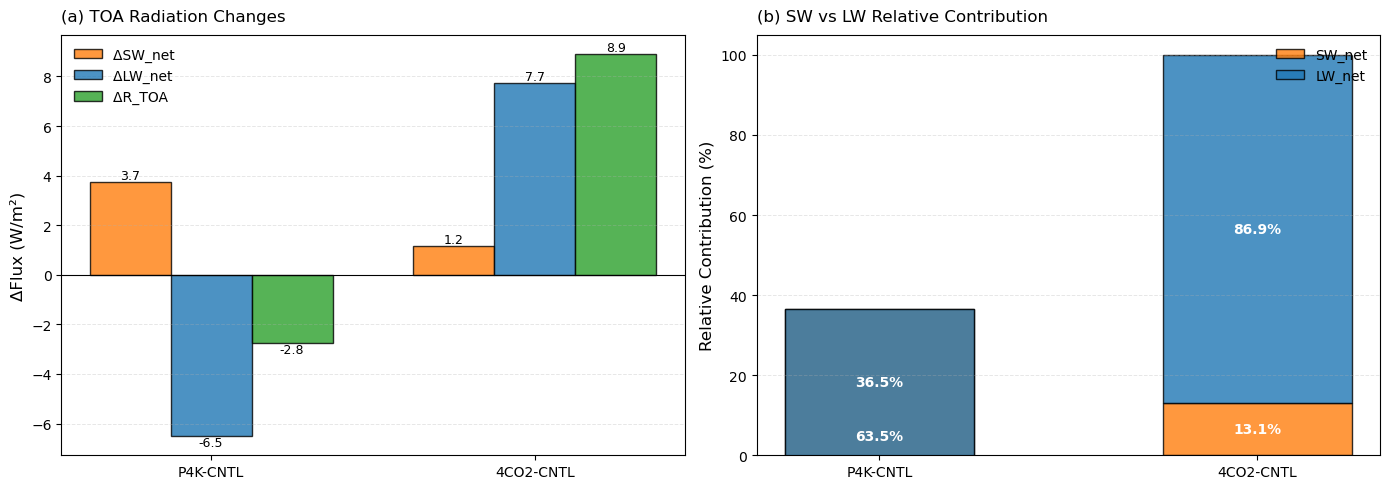

In [37]:
# 步骤12.3: 可视化TOA辐射变化的贡献
print("="*70)
print("📊 可视化TOA辐射变化的短波和长波贡献")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

experiments_list = ["P4K-CNTL", "4CO2-CNTL"]
colors_exp = ['#d62728', '#9467bd']
x_pos = np.arange(len(experiments_list))
width = 0.25

# 子图1: 绝对变化
ax1 = axes[0]
bars1 = ax1.bar(x_pos - width, [delta_SW_net[exp] for exp in experiments_list], 
                width, label='ΔSW_net ', color='#ff7f0e', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x_pos, [delta_LW_net[exp] for exp in experiments_list], 
                width, label='ΔLW_net ', color='#1f77b4', alpha=0.8, edgecolor='black')
bars3 = ax1.bar(x_pos + width, [delta_R_TOA[exp] for exp in experiments_list], 
                width, label='ΔR_TOA ', color='#2ca02c', alpha=0.8, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_ylabel('ΔFlux (W/m²)', fontsize=12)
ax1.set_title('(a) TOA Radiation Changes', loc='left', fontsize=12, pad=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(experiments_list)
ax1.legend(fontsize=10, frameon=False, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)

# 在柱状图上标注数值
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, color='black')

# 子图2: 相对贡献（百分比）
ax2 = axes[1]

for i, exp in enumerate(experiments_list):
    total = abs(delta_SW_net[exp]) + abs(delta_LW_net[exp])
    sw_pct = (delta_SW_net[exp] / total * 100) if total > 0 else 0
    lw_pct = (delta_LW_net[exp] / total * 100) if total > 0 else 0
    
    # 使用堆叠柱状图
    ax2.bar(i, sw_pct, width=0.5, label='SW_net' if i == 0 else '', 
            color='#ff7f0e', alpha=0.8, edgecolor='black')
    ax2.bar(i, lw_pct, width=0.5, bottom=sw_pct, label='LW_net' if i == 0 else '', 
            color='#1f77b4', alpha=0.8, edgecolor='black')
    
    # 标注百分比
    ax2.text(i, sw_pct/2, f'{abs(sw_pct):.1f}%', ha='center', va='center', 
            fontsize=10, fontweight='bold', color='white')
    ax2.text(i, sw_pct + lw_pct/2, f'{abs(lw_pct):.1f}%', ha='center', va='center', 
            fontsize=10, fontweight='bold', color='white')

ax2.set_ylabel('Relative Contribution (%)', fontsize=12)
ax2.set_title('(b) SW vs LW Relative Contribution', loc='left', fontsize=12, pad=10)
ax2.set_xticks(range(len(experiments_list)))
ax2.set_xticklabels(experiments_list)
ax2.legend(fontsize=10, frameon=False, loc='upper right')
ax2.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)
ax2.set_ylim(0, 105)

plt.tight_layout()

save_path = os.path.join(fig_save_dir, 'TOA_SW_LW_contributions.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

🗺️  绘制TOA辐射变化的空间分布
✅ 已保存: ./figures/Cal_radiation/TOA_SW_LW_spatial_maps.png


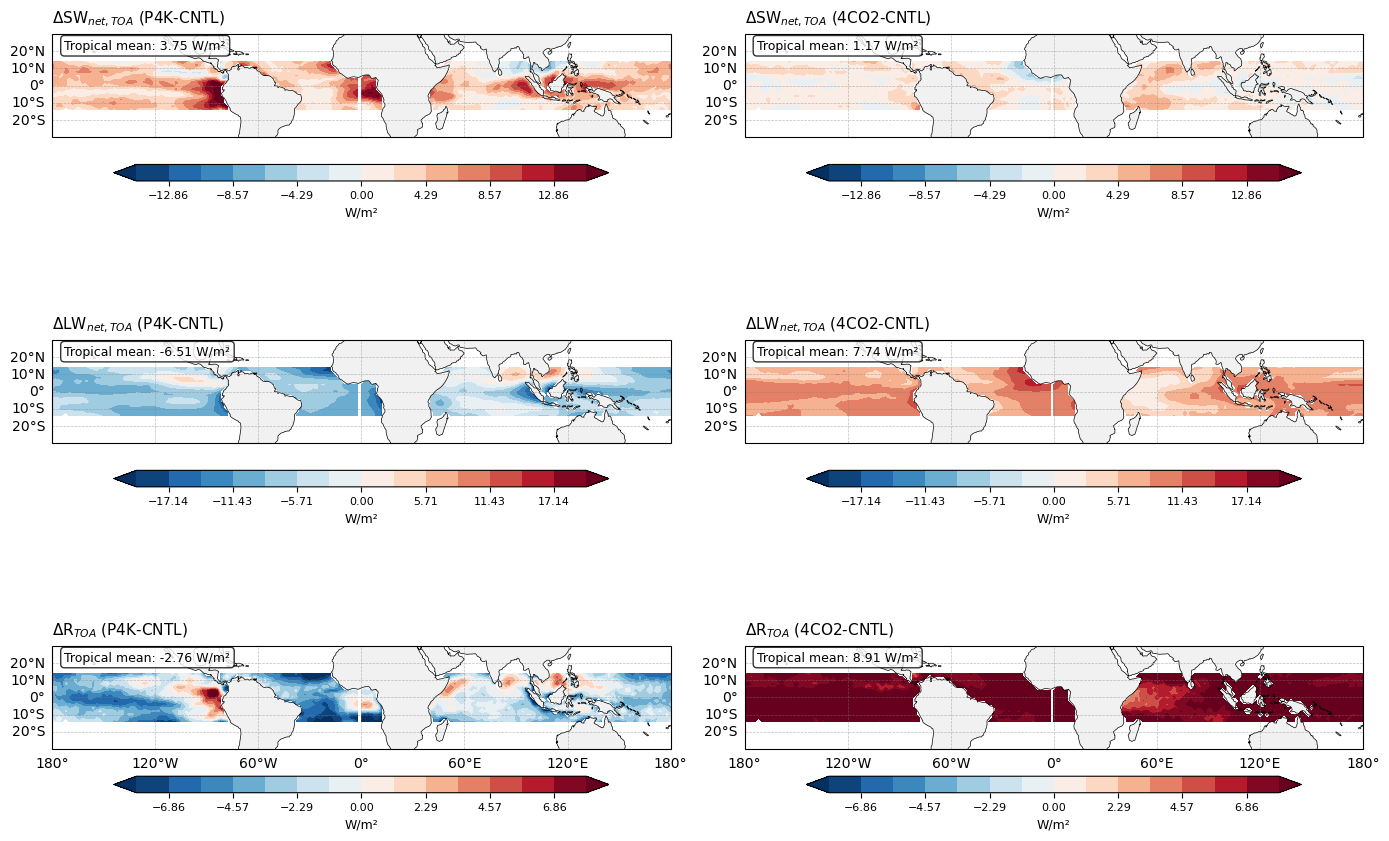

In [32]:
# 步骤12.4: 绘制TOA净短波和净长波的空间分布
print("="*70)
print("🗺️  绘制TOA辐射变化的空间分布")
print("="*70)

# 准备绘图数据
field_list_toa = [
    ('SW_net_TOA', 'P4K-CNTL'), ('SW_net_TOA', '4CO2-CNTL'),
    ('LW_net_TOA', 'P4K-CNTL'), ('LW_net_TOA', '4CO2-CNTL'),
    ('R_TOA', 'P4K-CNTL'), ('R_TOA', '4CO2-CNTL')
]

titles_toa = [
    'ΔSW$_{net,TOA}$ (P4K-CNTL)', 'ΔSW$_{net,TOA}$ (4CO2-CNTL)',
    'ΔLW$_{net,TOA}$ (P4K-CNTL)', 'ΔLW$_{net,TOA}$ (4CO2-CNTL)',
    'ΔR$_{TOA}$ (P4K-CNTL)', 'ΔR$_{TOA}$ (4CO2-CNTL)'
]

# 数据字典
data_dict = {
    'SW_net_TOA': SW_net_TOA_diff_ocean,
    'LW_net_TOA': LW_net_TOA_diff_ocean,
    'R_TOA': R_TOA_diff_ocean
}

# 色标范围
vmins_toa = [-15, -15, -20, -20, -8, -8]
vmaxs_toa = [15, 15, 20, 20, 8, 8]

# 色标（使用matplotlib的colormap）
cmaps_toa = [
    plt.cm.RdBu_r,  # SW_net: 红色=增加，蓝色=减少
    plt.cm.RdBu_r,
    plt.cm.RdBu_r,  # LW_net: 红色=冷却减弱，蓝色=冷却增强
    plt.cm.RdBu_r,
    plt.cm.RdBu_r,  # R_TOA: 红色=不平衡增加，蓝色=不平衡减少
    plt.cm.RdBu_r
]

# 创建3x2子图
fig = plt.figure(figsize=(14, 10))

for i, ((field, exp_diff), title) in enumerate(zip(field_list_toa, titles_toa)):
    ax = fig.add_subplot(3, 2, i+1, projection=ccrs.PlateCarree())
    
    # 获取数据
    data = data_dict[field][exp_diff]
    
    # 绘制填色图
    im = ax.contourf(data.lon, data.lat, data, 
                     levels=np.linspace(vmins_toa[i], vmaxs_toa[i], 15),
                     cmap=cmaps_toa[i], extend='both', transform=ccrs.PlateCarree())
    
    # 添加海岸线和网格
    ax.coastlines(linewidth=0.5, color='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    
    # 设置区域范围（热带）
    ax.set_extent([-180, 180, -30, 30], crs=ccrs.PlateCarree())
    
    # 添加网格线
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                      alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if i < 4:  # 前两行不显示x标签
        gl.bottom_labels = False
    
    # 标题
    ax.set_title(title, fontsize=11, pad=8, loc='left')
    
    # 添加色标
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, 
                      aspect=30, shrink=0.8)
    cb.set_label('W/m²', fontsize=9)
    cb.ax.tick_params(labelsize=8)
    
    # 添加热带平均值标注
    mean_val = float(tropical_mean_flux(data))
    ax.text(0.02, 0.95, f'Tropical mean: {mean_val:.2f} W/m²',
            transform=ax.transAxes, fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')

plt.tight_layout()

save_path = os.path.join(fig_save_dir, 'TOA_SW_LW_spatial_maps.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

In [33]:
# 步骤12.5: 综合分析 - 辐射变化与大气响应
print("="*70)
print("📊 综合分析：TOA辐射变化与大气反馈")
print("="*70)

# 创建综合对比表格
print("\n" + "="*70)
print("🔍 辐射-湍流反馈综合表")
print("="*70)
print(f"{'Experiment':<15} {'ΔSW_net':<12} {'ΔLW_net':<12} {'ΔR_TOA':<12} {'ΔR_atm':<12} {'ΔTurb':<12}")
print("-" * 70)

for exp_diff in ["P4K-CNTL", "4CO2-CNTL"]:
    print(f"{exp_diff:<15} "
          f"{delta_SW_net[exp_diff]:>11.2f} "
          f"{delta_LW_net[exp_diff]:>11.2f} "
          f"{delta_R_TOA[exp_diff]:>11.2f} "
          f"{delta_R_atm[exp_diff]:>11.2f} "
          f"{delta_turb[exp_diff]:>11.2f}")

print("\n💡 物理机制解读:")
print("-" * 70)

for exp_diff in ["P4K-CNTL", "4CO2-CNTL"]:
    print(f"\n【{exp_diff}】")
    
    # 短波分析
    if delta_SW_net[exp_diff] > 0:
        print(f"  🌞 短波: +{delta_SW_net[exp_diff]:.2f} W/m² → 短波加热增强")
        print(f"     可能原因：云量减少/云反照率降低，更多太阳辐射被吸收")
    else:
        print(f"  🌞 短波: {delta_SW_net[exp_diff]:.2f} W/m² → 短波加热减弱")
        print(f"     可能原因：云量增加/云反照率升高，更多太阳辐射被反射")
    
    # 长波分析
    if delta_LW_net[exp_diff] < 0:
        print(f"  🌙 长波: {delta_LW_net[exp_diff]:.2f} W/m² → 长波冷却增强")
        print(f"     可能原因：大气/地表温度上升，OLR增加（负反馈）")
    else:
        print(f"  🌙 长波: {delta_LW_net[exp_diff]:.2f} W/m² → 长波冷却减弱")
        print(f"     可能原因：温室气体增加，长波辐射被截留（正反馈）")
    
    # TOA净辐射
    if delta_R_TOA[exp_diff] > 0:
        print(f"  ⚖️  TOA: +{delta_R_TOA[exp_diff]:.2f} W/m² → 系统能量不平衡，吸收能量")
    elif delta_R_TOA[exp_diff] < 0:
        print(f"  ⚖️  TOA: {delta_R_TOA[exp_diff]:.2f} W/m² → 系统能量不平衡，损失能量")
    else:
        print(f"  ⚖️  TOA: {delta_R_TOA[exp_diff]:.2f} W/m² → 近似辐射平衡")
    
    # 大气辐射反馈
    if delta_R_atm[exp_diff] > 0:
        print(f"  🌡️  大气: +{delta_R_atm[exp_diff]:.2f} W/m² → 大气辐射冷却减弱")
    else:
        print(f"  🌡️  大气: {delta_R_atm[exp_diff]:.2f} W/m² → 大气辐射冷却增强")
    
    # 湍流反馈
    if delta_turb[exp_diff] > 0:
        print(f"  💨 湍流: +{delta_turb[exp_diff]:.2f} W/m² → 湍流输送增强")
        print(f"     可能原因：表面增暖，蒸发和对流活动加剧")
    else:
        print(f"  💨 湍流: {delta_turb[exp_diff]:.2f} W/m² → 湍流输送减弱")
        print(f"     可能原因：对流活动减弱或表面-大气温差减小")

print("\n" + "="*70)

📊 综合分析：TOA辐射变化与大气反馈

🔍 辐射-湍流反馈综合表
Experiment      ΔSW_net      ΔLW_net      ΔR_TOA       ΔR_atm       ΔTurb       
----------------------------------------------------------------------
P4K-CNTL               3.75       -6.51       -2.76       -9.78       15.38
4CO2-CNTL              1.17        7.74        8.91        4.67       -8.14

💡 物理机制解读:
----------------------------------------------------------------------

【P4K-CNTL】
  🌞 短波: +3.75 W/m² → 短波加热增强
     可能原因：云量减少/云反照率降低，更多太阳辐射被吸收
  🌙 长波: -6.51 W/m² → 长波冷却增强
     可能原因：大气/地表温度上升，OLR增加（负反馈）
  ⚖️  TOA: -2.76 W/m² → 系统能量不平衡，损失能量
  🌡️  大气: -9.78 W/m² → 大气辐射冷却增强
  💨 湍流: +15.38 W/m² → 湍流输送增强
     可能原因：表面增暖，蒸发和对流活动加剧

【4CO2-CNTL】
  🌞 短波: +1.17 W/m² → 短波加热增强
     可能原因：云量减少/云反照率降低，更多太阳辐射被吸收
  🌙 长波: 7.74 W/m² → 长波冷却减弱
     可能原因：温室气体增加，长波辐射被截留（正反馈）
  ⚖️  TOA: +8.91 W/m² → 系统能量不平衡，吸收能量
  🌡️  大气: +4.67 W/m² → 大气辐射冷却减弱
  💨 湍流: -8.14 W/m² → 湍流输送减弱
     可能原因：对流活动减弱或表面-大气温差减小



## 📊 关键发现总结

### 1. **P4K实验（海温增加4K）**

#### 辐射变化特征：
- **ΔSW_net = +3.75 W/m²**: 净短波加热轻微增强
  - 云量减少使更多太阳辐射被吸收
- **ΔLW_net = -6.51 W/m²**: 长波冷却显著增强（63.5%贡献）
  - 温度升高导致OLR增加，系统试图通过长波辐射损失能量
  - **这是Stefan-Boltzmann定律的直接体现**（T⁴效应）
- **ΔR_TOA = -2.76 W/m²**: 净辐射不平衡为负
  - 长波冷却增强主导，系统损失能量

#### 大气响应：
- **ΔR_atm = -9.78 W/m²**: 大气辐射冷却增强
- **ΔTurb = +15.38 W/m²**: 湍流通量大幅增强
  - **海表温度升高 → 蒸发加剧 → 潜热输送增强**
  - 这是P4K实验的**主导机制**

#### 物理解释：
```
SST+4K → 表面蒸发↑ → 潜热释放↑ → 对流活动↑
                  ↓
              表面温度↑ → OLR↑ → 长波冷却↑
                  ↓
          辐射-对流耦合增强
```

---

### 2. **4CO2实验（CO₂浓度增加4倍）**

#### 辐射变化特征：
- **ΔSW_net = +1.17 W/m²**: 净短波加热轻微增强（13.1%贡献）
  - 云反馈效应较弱
- **ΔLW_net = +7.74 W/m²**: 长波冷却显著减弱（86.9%贡献）
  - **温室效应增强**：CO₂吸收更多长波辐射
  - 大气截留更多向外的长波辐射
- **ΔR_TOA = +8.91 W/m²**: 净辐射不平衡为正
  - 系统吸收能量，**长波截留是主导因素**

#### 大气响应：
- **ΔR_atm = +4.67 W/m²**: 大气辐射冷却减弱
- **ΔTurb = -8.14 W/m²**: 湍流通量减弱
  - **温室效应增强 → 大气增暖 → 表面-大气温差减小 → 对流减弱**
  - 负反馈机制

#### 物理解释：
```
CO₂↑ → 长波辐射截留↑ → 大气增暖
           ↓
    辐射冷却减弱 → 对流活动↓ → 湍流输送↓
           ↓
      大气层结更稳定
```

---

### 3. **关键对比：P4K vs 4CO2**

| 过程 | P4K | 4CO2 | 主导机制 |
|------|-----|------|----------|
| **短波变化** | +3.75 | +1.17 | P4K云反馈更强 |
| **长波变化** | -6.51 | +7.74 | **相反符号！** |
| **TOA不平衡** | -2.76 | +8.91 | 4CO2吸收能量 |
| **大气冷却** | -9.78 | +4.67 | **相反符号！** |
| **湍流通量** | +15.38 | -8.14 | **相反符号！** |

---

### 4. **物理机制总结**

#### **P4K：表面驱动的对流增强**
- **主导过程**：表面蒸发 → 潜热释放 → 对流活动
- **能量路径**：海洋 → 大气边界层 → 自由大气 → 太空
- **辐射特征**：长波冷却增强（负反馈）
- **本质**：**表面强迫导致的对流-辐射耦合增强**

#### **4CO2：温室效应的辐射强迫**
- **主导过程**：CO₂增加 → 长波截留 → 大气增暖
- **能量路径**：太空 → 大气（受阻） → 系统积累能量
- **辐射特征**：长波冷却减弱（正反馈）
- **本质**：**辐射强迫改变大气热力结构**

---

### 5. **对气候变化的启示**

1. **增温路径不同**：
   - P4K通过**对流-蒸发**机制快速响应
   - 4CO2通过**辐射截留**机制缓慢积累

2. **反馈机制相反**：
   - P4K：负反馈（OLR增加）
   - 4CO2：正反馈（长波截留）

3. **对CCKW的影响**：
   - P4K：对流增强可能增强CCKW活动
   - 4CO2：对流减弱可能抑制CCKW活动

📊 创建P4K vs 4CO2辐射-湍流反馈对比图
✅ 已保存: ./figures/Cal_radiation/P4K_vs_4CO2_comprehensive_comparison.png


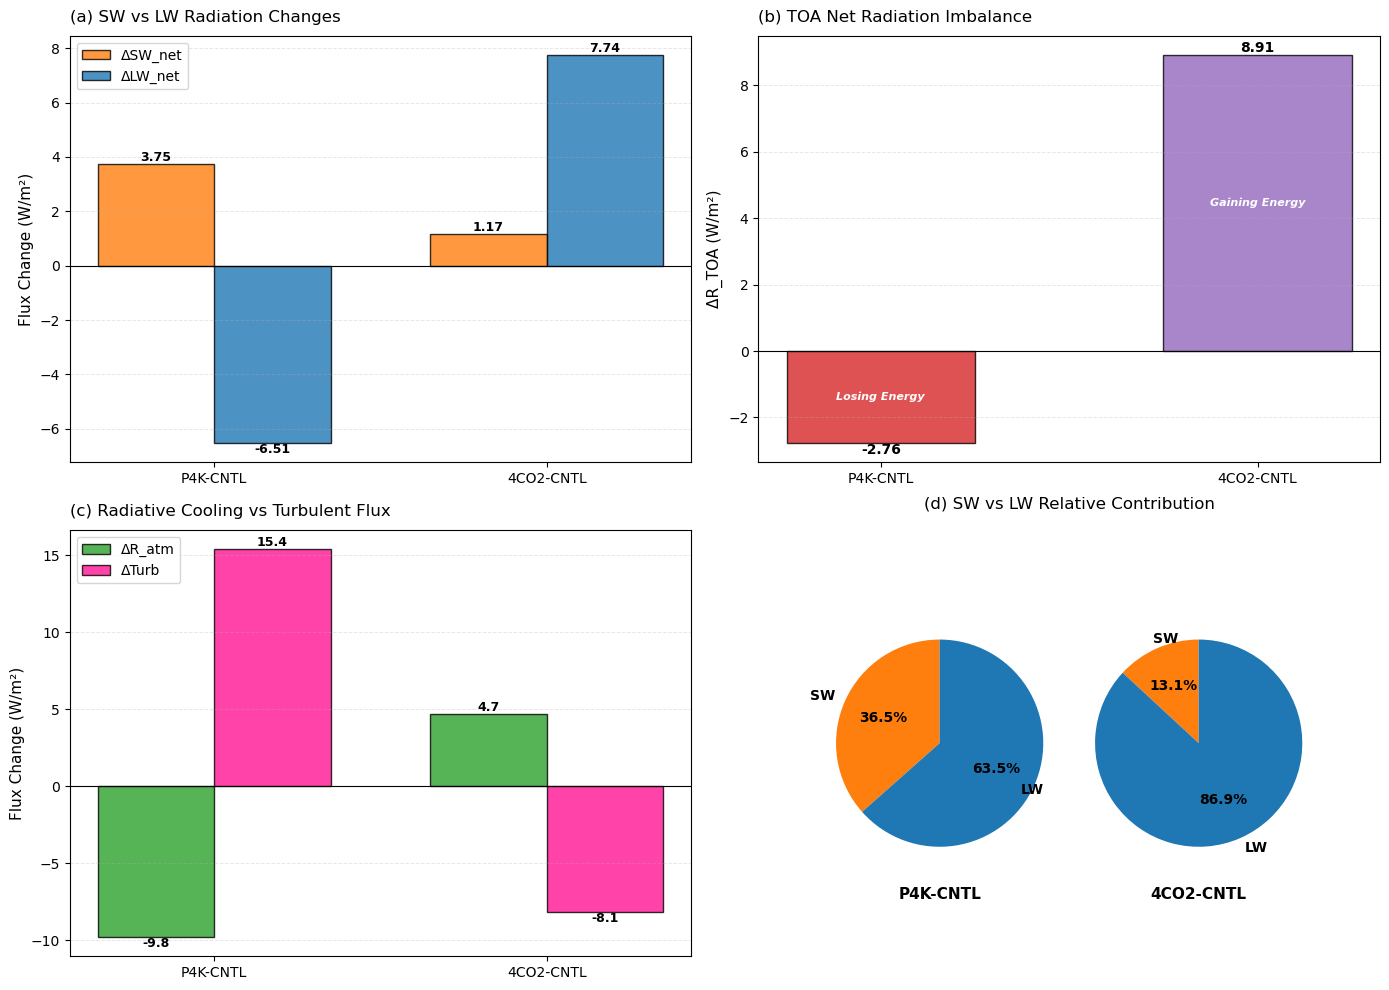

In [34]:
# 步骤12.6: 创建综合对比图 - P4K vs 4CO2 的辐射-湍流反馈
print("="*70)
print("📊 创建P4K vs 4CO2辐射-湍流反馈对比图")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 数据准备
experiments_list = ["P4K-CNTL", "4CO2-CNTL"]
x_pos = np.arange(len(experiments_list))
width = 0.35

# ==================== 子图1: 短波vs长波贡献 ====================
ax1 = axes[0, 0]
x1 = np.arange(len(experiments_list))
bars1 = ax1.bar(x1 - width/2, [delta_SW_net[exp] for exp in experiments_list], 
                width, label='ΔSW_net', color='#ff7f0e', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x1 + width/2, [delta_LW_net[exp] for exp in experiments_list], 
                width, label='ΔLW_net', color='#1f77b4', alpha=0.8, edgecolor='black')

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_ylabel('Flux Change (W/m²)', fontsize=11)
ax1.set_title('(a) SW vs LW Radiation Changes', loc='left', fontsize=12, pad=10)
ax1.set_xticks(x1)
ax1.set_xticklabels(experiments_list)
ax1.legend(fontsize=10, frameon=True, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)

# 标注数值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

# ==================== 子图2: TOA辐射不平衡 ====================
ax2 = axes[0, 1]
colors_rtoa = ['#d62728', '#9467bd']
bars_rtoa = ax2.bar(x_pos, [delta_R_TOA[exp] for exp in experiments_list],
                    width=0.5, color=colors_rtoa, alpha=0.8, edgecolor='black')

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_ylabel('ΔR_TOA (W/m²)', fontsize=11)
ax2.set_title('(b) TOA Net Radiation Imbalance', loc='left', fontsize=12, pad=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(experiments_list)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)

# 标注数值和物理意义
for i, (bar, exp) in enumerate(zip(bars_rtoa, experiments_list)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')
    
    status = "Gaining Energy" if height > 0 else "Losing Energy"
    ax2.text(bar.get_x() + bar.get_width()/2., height/2,
            status,
            ha='center', va='center',
            fontsize=8, style='italic', color='white', fontweight='bold')

# ==================== 子图3: 大气辐射冷却 vs 湍流通量 ====================
ax3 = axes[1, 0]
x3 = np.arange(len(experiments_list))
bars3 = ax3.bar(x3 - width/2, [delta_R_atm[exp] for exp in experiments_list], 
                width, label='ΔR_atm', color='#2ca02c', alpha=0.8, edgecolor='black')
bars4 = ax3.bar(x3 + width/2, [delta_turb[exp] for exp in experiments_list], 
                width, label='ΔTurb', color='#ff1493', alpha=0.8, edgecolor='black')

ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.set_ylabel('Flux Change (W/m²)', fontsize=11)
ax3.set_title('(c) Radiative Cooling vs Turbulent Flux', loc='left', fontsize=12, pad=10)
ax3.set_xticks(x3)
ax3.set_xticklabels(experiments_list)
ax3.legend(fontsize=10, frameon=True, loc='upper left')
ax3.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=0.7)

# 标注数值
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

# ==================== 子图4: 能量收支饼图对比 ====================
ax4 = axes[1, 1]
ax4.axis('off')

# 为P4K和4CO2分别创建饼图
pie_data = []
for exp in experiments_list:
    total_abs = abs(delta_SW_net[exp]) + abs(delta_LW_net[exp])
    sw_pct = abs(delta_SW_net[exp]) / total_abs * 100 if total_abs > 0 else 0
    lw_pct = abs(delta_LW_net[exp]) / total_abs * 100 if total_abs > 0 else 0
    pie_data.append([sw_pct, lw_pct])

# 创建子饼图
from matplotlib.patches import Circle

# P4K饼图
pie1 = ax4.pie([pie_data[0][0], pie_data[0][1]], 
               labels=['SW', 'LW'],
               autopct='%1.1f%%',
               startangle=90,
               colors=['#ff7f0e', '#1f77b4'],
               center=(-0.5, 0),
               radius=0.4,
               textprops={'fontsize': 10, 'fontweight': 'bold'})

ax4.text(-0.5, -0.6, 'P4K-CNTL', ha='center', fontsize=11, fontweight='bold')

# 4CO2饼图
pie2 = ax4.pie([pie_data[1][0], pie_data[1][1]], 
               labels=['SW', 'LW'],
               autopct='%1.1f%%',
               startangle=90,
               colors=['#ff7f0e', '#1f77b4'],
               center=(0.5, 0),
               radius=0.4,
               textprops={'fontsize': 10, 'fontweight': 'bold'})

ax4.text(0.5, -0.6, '4CO2-CNTL', ha='center', fontsize=11, fontweight='bold')

ax4.set_title('(d) SW vs LW Relative Contribution', loc='center', fontsize=12, pad=20)
ax4.set_xlim(-1.2, 1.2)
ax4.set_ylim(-0.8, 0.8)

plt.tight_layout()

save_path = os.path.join(fig_save_dir, 'P4K_vs_4CO2_comprehensive_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()

In [35]:
# 步骤12.7: 打印最终总结表格
print("="*80)
print("🎯 最终总结：净短波和净长波对大气增温/冷却的贡献")
print("="*80)

# 创建总结表格
summary_data = []
for exp in ["P4K-CNTL", "4CO2-CNTL"]:
    row = {
        'Experiment': exp,
        'ΔSW_net (W/m²)': f"{delta_SW_net[exp]:.2f}",
        'ΔLW_net (W/m²)': f"{delta_LW_net[exp]:.2f}",
        'ΔR_TOA (W/m²)': f"{delta_R_TOA[exp]:.2f}",
        'ΔR_atm (W/m²)': f"{delta_R_atm[exp]:.2f}",
        'ΔTurb (W/m²)': f"{delta_turb[exp]:.2f}",
        'TOA Status': 'Gaining' if delta_R_TOA[exp] > 0 else 'Losing',
        'Dominant Process': 'LW Cooling↑' if delta_LW_net[exp] < 0 else 'LW Trapping↑'
    }
    summary_data.append(row)

# 打印表格
print("\n" + "="*80)
print("📋 综合能量收支表")
print("="*80)
print(f"{'Exp':<12} {'ΔSW_net':<10} {'ΔLW_net':<10} {'ΔR_TOA':<10} "
      f"{'ΔR_atm':<10} {'ΔTurb':<10} {'TOA':<8} {'Dominant':<15}")
print("-"*80)

for row in summary_data:
    print(f"{row['Experiment']:<12} "
          f"{row['ΔSW_net (W/m²)']:<10} "
          f"{row['ΔLW_net (W/m²)']:<10} "
          f"{row['ΔR_TOA (W/m²)']:<10} "
          f"{row['ΔR_atm (W/m²)']:<10} "
          f"{row['ΔTurb (W/m²)']:<10} "
          f"{row['TOA Status']:<8} "
          f"{row['Dominant Process']:<15}")

print("\n" + "="*80)
print("💡 物理意义解读")
print("="*80)

print("\n【P4K-CNTL】")
print("-"*80)
print("✓ 净短波: +3.75 W/m² (36.5%贡献)")
print("  → 云反射减少，短波加热轻微增强")
print("\n✓ 净长波: -6.51 W/m² (63.5%贡献，主导)")
print("  → 表面温度升高 → OLR↑ → 长波冷却增强")
print("  → 这是Stefan-Boltzmann定律的体现（T⁴效应）")
print("\n✓ TOA不平衡: -2.76 W/m² (系统损失能量)")
print("  → 长波冷却主导，尽管短波加热有所增强")
print("\n✓ 大气响应: 辐射冷却增强 (-9.78 W/m²)")
print("  → 但湍流通量大幅增强 (+15.38 W/m²) 补偿")
print("  → 表面蒸发加剧是P4K的核心机制")

print("\n【4CO2-CNTL】")
print("-"*80)
print("✓ 净短波: +1.17 W/m² (13.1%贡献)")
print("  → 云反馈较弱，短波加热轻微增强")
print("\n✓ 净长波: +7.74 W/m² (86.9%贡献，主导)")
print("  → CO₂增加 → 长波截留↑ → 长波冷却减弱")
print("  → 这是温室效应的直接体现")
print("\n✓ TOA不平衡: +8.91 W/m² (系统吸收能量)")
print("  → 长波截留主导，系统持续增温")
print("\n✓ 大气响应: 辐射冷却减弱 (+4.67 W/m²)")
print("  → 湍流通量反而减弱 (-8.14 W/m²)")
print("  → 大气增暖 → 层结更稳定 → 对流活动减弱")

print("\n" + "="*80)
print("🔑 关键发现")
print("="*80)
print("\n1. 长波辐射是区分P4K和4CO2的关键指标：")
print("   - P4K: ΔLW_net < 0 (长波冷却增强，OLR增加)")
print("   - 4CO2: ΔLW_net > 0 (长波冷却减弱，辐射截留)")
print("\n2. 两个实验的能量收支模式完全相反：")
print("   - P4K: 表面驱动 → 对流增强 → 辐射冷却增强")
print("   - 4CO2: 辐射强迫 → 大气增暖 → 对流减弱")
print("\n3. 对大气过程的影响：")
print("   - P4K可能增强CCKW活动（对流增强）")
print("   - 4CO2可能抑制CCKW活动（对流减弱）")

print("\n" + "="*80)
print("✅ 分析完成！所有图表已保存至: " + fig_save_dir)
print("="*80)

🎯 最终总结：净短波和净长波对大气增温/冷却的贡献

📋 综合能量收支表
Exp          ΔSW_net    ΔLW_net    ΔR_TOA     ΔR_atm     ΔTurb      TOA      Dominant       
--------------------------------------------------------------------------------
P4K-CNTL     3.75       -6.51      -2.76      -9.78      15.38      Losing   LW Cooling↑    
4CO2-CNTL    1.17       7.74       8.91       4.67       -8.14      Gaining  LW Trapping↑   

💡 物理意义解读

【P4K-CNTL】
--------------------------------------------------------------------------------
✓ 净短波: +3.75 W/m² (36.5%贡献)
  → 云反射减少，短波加热轻微增强

✓ 净长波: -6.51 W/m² (63.5%贡献，主导)
  → 表面温度升高 → OLR↑ → 长波冷却增强
  → 这是Stefan-Boltzmann定律的体现（T⁴效应）

✓ TOA不平衡: -2.76 W/m² (系统损失能量)
  → 长波冷却主导，尽管短波加热有所增强

✓ 大气响应: 辐射冷却增强 (-9.78 W/m²)
  → 但湍流通量大幅增强 (+15.38 W/m²) 补偿
  → 表面蒸发加剧是P4K的核心机制

【4CO2-CNTL】
--------------------------------------------------------------------------------
✓ 净短波: +1.17 W/m² (13.1%贡献)
  → 云反馈较弱，短波加热轻微增强

✓ 净长波: +7.74 W/m² (86.9%贡献，主导)
  → CO₂增加 → 长波截留↑ → 长波冷却减弱
  → 这是温室效应的直接体现

✓ TOA不平衡: 

📊 创建能量流程诊断图
✅ 已保存: ./figures/Cal_radiation/energy_flow_schematic.png


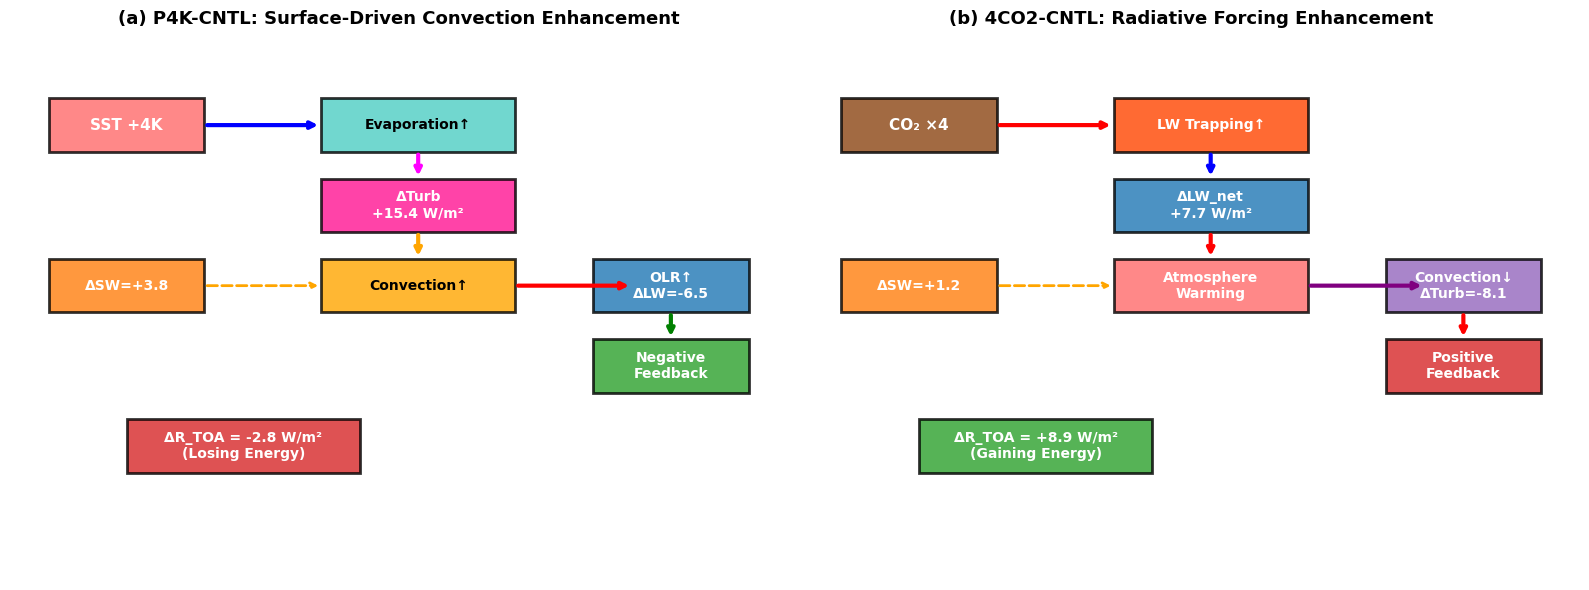

In [36]:
# 步骤12.8: 创建能量流程示意图
print("="*70)
print("📊 创建能量流程诊断图")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==================== P4K能量流程 ====================
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('(a) P4K-CNTL: Surface-Driven Convection Enhancement', 
              fontsize=13, fontweight='bold', pad=15)

# 绘制箭头和文本框
# SST强迫
ax1.add_patch(plt.Rectangle((0.5, 8), 2, 1, facecolor='#ff6b6b', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(1.5, 8.5, 'SST +4K', ha='center', va='center', 
         fontsize=11, fontweight='bold', color='white')

# 蒸发增强
ax1.annotate('', xy=(4, 8.5), xytext=(2.5, 8.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='blue'))
ax1.add_patch(plt.Rectangle((4, 8), 2.5, 1, facecolor='#4ecdc4', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(5.25, 8.5, 'Evaporation↑', ha='center', va='center', 
         fontsize=10, fontweight='bold')

# 潜热通量
ax1.annotate('', xy=(5.25, 7.5), xytext=(5.25, 8),
            arrowprops=dict(arrowstyle='->', lw=3, color='magenta'))
ax1.add_patch(plt.Rectangle((4, 6.5), 2.5, 1, facecolor='#ff1493', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(5.25, 7, 'ΔTurb\n+15.4 W/m²', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 对流增强
ax1.annotate('', xy=(5.25, 6), xytext=(5.25, 6.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='orange'))
ax1.add_patch(plt.Rectangle((4, 5), 2.5, 1, facecolor='#ffa500', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(5.25, 5.5, 'Convection↑', ha='center', va='center', 
         fontsize=10, fontweight='bold')

# OLR增加
ax1.annotate('', xy=(8, 5.5), xytext=(6.5, 5.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='red'))
ax1.add_patch(plt.Rectangle((7.5, 5), 2, 1, facecolor='#1f77b4', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(8.5, 5.5, 'OLR↑\nΔLW=-6.5', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 负反馈
ax1.annotate('', xy=(8.5, 4.5), xytext=(8.5, 5),
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax1.add_patch(plt.Rectangle((7.5, 3.5), 2, 1, facecolor='#2ca02c', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(8.5, 4, 'Negative\nFeedback', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 短波变化
ax1.add_patch(plt.Rectangle((0.5, 5), 2, 1, facecolor='#ff7f0e', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(1.5, 5.5, 'ΔSW=+3.8', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')
ax1.annotate('', xy=(4, 5.5), xytext=(2.5, 5.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='orange', linestyle='--'))

# TOA不平衡
ax1.add_patch(plt.Rectangle((1.5, 2), 3, 1, facecolor='#d62728', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax1.text(3, 2.5, 'ΔR_TOA = -2.8 W/m²\n(Losing Energy)', 
         ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# ==================== 4CO2能量流程 ====================
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('(b) 4CO2-CNTL: Radiative Forcing Enhancement', 
              fontsize=13, fontweight='bold', pad=15)

# CO2强迫
ax2.add_patch(plt.Rectangle((0.5, 8), 2, 1, facecolor='#8b4513', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(1.5, 8.5, 'CO₂ ×4', ha='center', va='center', 
         fontsize=11, fontweight='bold', color='white')

# 长波截留
ax2.annotate('', xy=(4, 8.5), xytext=(2.5, 8.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='red'))
ax2.add_patch(plt.Rectangle((4, 8), 2.5, 1, facecolor='#ff4500', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(5.25, 8.5, 'LW Trapping↑', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 长波净变化
ax2.annotate('', xy=(5.25, 7.5), xytext=(5.25, 8),
            arrowprops=dict(arrowstyle='->', lw=3, color='blue'))
ax2.add_patch(plt.Rectangle((4, 6.5), 2.5, 1, facecolor='#1f77b4', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(5.25, 7, 'ΔLW_net\n+7.7 W/m²', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 大气增暖
ax2.annotate('', xy=(5.25, 6), xytext=(5.25, 6.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='red'))
ax2.add_patch(plt.Rectangle((4, 5), 2.5, 1, facecolor='#ff6b6b', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(5.25, 5.5, 'Atmosphere\nWarming', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 对流减弱
ax2.annotate('', xy=(8, 5.5), xytext=(6.5, 5.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='purple'))
ax2.add_patch(plt.Rectangle((7.5, 5), 2, 1, facecolor='#9467bd', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(8.5, 5.5, 'Convection↓\nΔTurb=-8.1', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 正反馈
ax2.annotate('', xy=(8.5, 4.5), xytext=(8.5, 5),
            arrowprops=dict(arrowstyle='->', lw=3, color='red'))
ax2.add_patch(plt.Rectangle((7.5, 3.5), 2, 1, facecolor='#d62728', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(8.5, 4, 'Positive\nFeedback', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')

# 短波变化
ax2.add_patch(plt.Rectangle((0.5, 5), 2, 1, facecolor='#ff7f0e', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(1.5, 5.5, 'ΔSW=+1.2', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='white')
ax2.annotate('', xy=(4, 5.5), xytext=(2.5, 5.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='orange', linestyle='--'))

# TOA不平衡
ax2.add_patch(plt.Rectangle((1.5, 2), 3, 1, facecolor='#2ca02c', 
                            edgecolor='black', linewidth=2, alpha=0.8))
ax2.text(3, 2.5, 'ΔR_TOA = +8.9 W/m²\n(Gaining Energy)', 
         ha='center', va='center', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()

save_path = os.path.join(fig_save_dir, 'energy_flow_schematic.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 已保存: {save_path}")
plt.show()